In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load data with proper date parsing
final_data = pd.read_csv(
    r'C:\Users\Hp\OneDrive\Desktop\Data\Data Time series project\Morocco_Electricity_Combined_2008_2025.csv',
    index_col='Date',
    parse_dates=True
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    final_data.index,
    final_data['Electricity_Consumption'],
    color='#1f77b4',
    linewidth=1.8,
    label='Electricity Consumption'
)

# Fill area under the curve for visual appeal
"""
ax.fill_between(
    final_data.index,
    final_data['Electricity_Consumption'],
    alpha=0.15,
    color='#1f77b4'
)
"""
# Titles and labels
ax.set_title('Morocco Monthly Electricity Consumption (2008–2025)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Electricity Consumption (GWh)', fontsize=13)

# Grid and style
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12)
ax.tick_params(axis='x', rotation=30)

# Add min/max annotations
max_val = final_data['Electricity_Consumption'].max()
min_val = final_data['Electricity_Consumption'].min()
max_date = final_data['Electricity_Consumption'].idxmax()
min_date = final_data['Electricity_Consumption'].idxmin()
"""
ax.annotate(f'Max: {max_val:.0f} GWh',
            xy=(max_date, max_val),
            xytext=(20, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax.annotate(f'Min: {min_val:.0f} GWh',
            xy=(min_date, min_val),
            xytext=(20, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10, color='green')
"""
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'numpy'

C:\Users\Hp\AppData\Local\Temp\ipykernel_21764\4061297162.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('tab20', len(years))


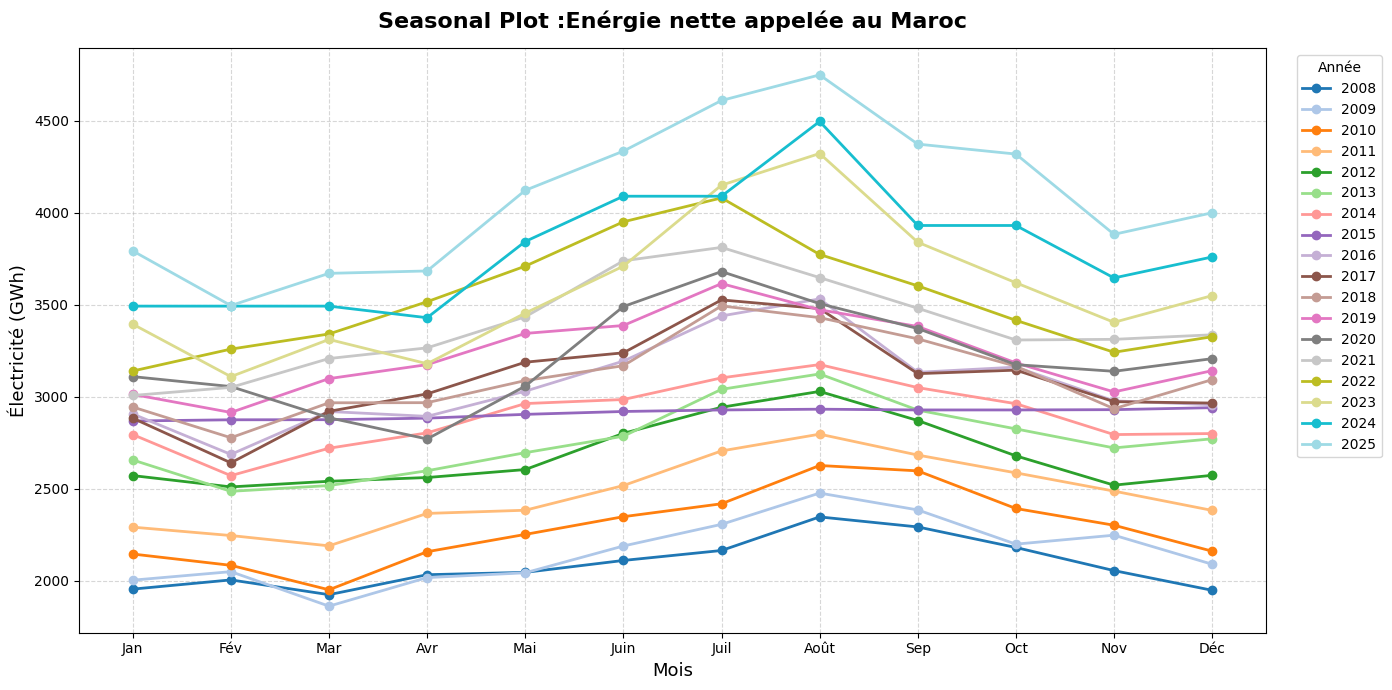

In [3]:
# Création des colonnes Année et Mois à partir de l'index Date
final_data['Year'] = final_data.index.year
final_data['Month'] = final_data.index.month

# --- Seasonal Plot ---
fig, ax = plt.subplots(figsize=(14, 7))

# Obtenir les années uniques du dataset
years = final_data['Year'].unique()

# Utilisation d'une palette de couleur pour différencier les années ("tab20" a 20 couleurs par défaut)
colormap = plt.cm.get_cmap('tab20', len(years))

# On trace une courbe mois par mois, pour chaque année spécifiquement
for i, year in enumerate(years):
    data_year = final_data[final_data['Year'] == year].sort_values(by='Month')
    ax.plot(data_year['Month'], data_year['Electricity_Consumption'], 
            marker='o', label=str(year), color=colormap(i), linewidth=2)

# --- Personnalisation de l'affichage ---
ax.set_title("Seasonal Plot :Enérgie nette appelée au Maroc", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Mois', fontsize=13)
ax.set_ylabel('Électricité (GWh)', fontsize=13)

# Mettre les noms des mois sur l'axe des x au lieu des numéros (1 à 12)
months_names = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months_names)

# Placer la légende à l'extérieur pour ne pas bloquer les courbes
ax.legend(title='Année', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

# Ajouter une grille légère pour une meilleure visibilité
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


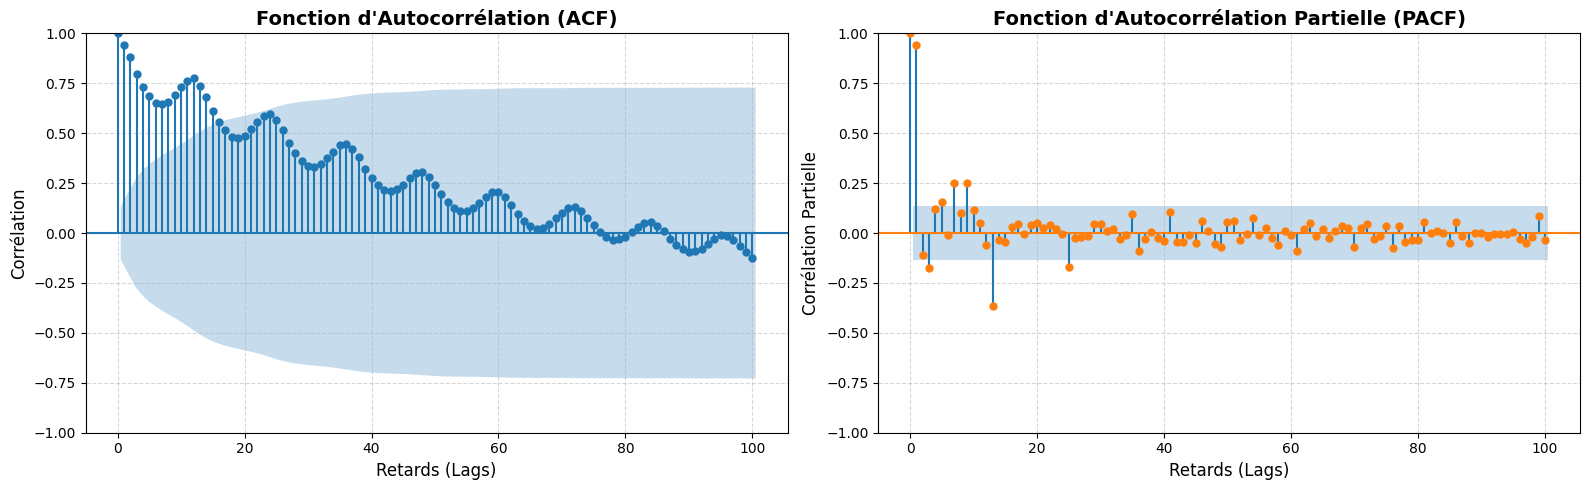

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Paramètre : on choisit le nombre de retards (lags) à afficher.
# Pour des données mensuelles, 40 lags (environ 3 ans) est un bon choix pour voir la saisonnalité.
n_lags = 100

# --- Graphiques ACF et PACF ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. ACF (Autocorrelation Function)
# On utilise dropna() au cas où il y aurait des valeurs manquantes après d'éventuelles différences
plot_acf(final_data['Electricity_Consumption'].dropna(), lags=n_lags, ax=axes[0], color='#1f77b4')
axes[0].set_title('Fonction d\'Autocorrélation (ACF)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Retards (Lags)', fontsize=12)
axes[0].set_ylabel('Corrélation', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. PACF (Partial Autocorrelation Function)
# La méthode 'ywm' est recommandée par défaut dans les versions récentes de statsmodels
plot_pacf(final_data['Electricity_Consumption'].dropna(), lags=n_lags, ax=axes[1], method='ywm', color='#ff7f0e')
axes[1].set_title('Fonction d\'Autocorrélation Partielle (PACF)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Retards (Lags)', fontsize=12)
axes[1].set_ylabel('Corrélation Partielle', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss
import warnings




# --- 1. Test ADF (Augmented Dickey-Fuller) ---
# Hypothèse nulle (H0) : La série a une racine unitaire (non stationnaire)
def adf_test(series):
    print("=== Test d'Augmented Dickey-Fuller (ADF) ===")
    result = adfuller(series.dropna(), autolag='AIC')
    labels = ['Statistique de test', 'Valeur p (p-value)', 'Lags utilisés', 'Nombre d\'observations']
    out = pd.Series(result[0:4], index=labels)
    for key, val in result[4].items():
        out[f'Valeur critique ({key})'] = val
    print(out.to_string())
    
    if result[1] <= 0.05:
        print("-> Conclusion : Rejet de H0. La série est stationnaire.\n")
    else:
        print("-> Conclusion : Impossible de rejeter H0. La série est non stationnaire.\n")

# --- 2. Test KPSS ---
# Hypothèse nulle (H0) : La série est stationnaire (autour d'une constante/tendance)
def kpss_test(series):
    print("=== Test KPSS ===")
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore") # Ignore les alertes concernant les p-values extrêmes
        result = kpss(series.dropna(), regression='c', nlags='auto') # 'c' pour une stationnarité autour d'une constante
        
    labels = ['Statistique de test', 'Valeur p (p-value)', 'Lags utilisés']
    out = pd.Series(result[0:3], index=labels)
    for key, val in result[3].items():
        out[f'Valeur critique ({key})'] = val
    print(out.to_string())
    
    if result[1] <= 0.05:
        print("-> Conclusion : Rejet de H0. La série est non stationnaire.\n")
    else:
        print("-> Conclusion : Impossible de rejeter H0. La série est stationnaire.\n")

# --- 3. Test PP (Phillips-Perron) ---
# Hypothèse nulle (H0) : La série a une racine unitaire (non stationnaire)
def pp_test(series):
    print("=== Test de Phillips-Perron (PP) ===")
    try:
        from arch.unitroot import PhillipsPerron
        pp = PhillipsPerron(series.dropna())
        print(pp.summary().as_text())
        
        if pp.pvalue <= 0.05:
            print("-> Conclusion : Rejet de H0. La série est stationnaire.\n")
        else:
            print("-> Conclusion : Impossible de rejeter H0. La série est non stationnaire.\n")
    except ImportError:
        print("Attention : Le package 'arch' n'est pas installé.")
        print("Pour lancer le test PP, exécutez '!pip install arch' dans votre notebook puis relancez cette cellule.\n")

ts_1d = final_data['Electricity_Consumption']

print("ÉVALUATION DE LA STATIONNARITÉ DE LA SÉRIE ORIGINALE\n" + "-"*50)
adf_test(ts_1d)
kpss_test(ts_1d)
pp_test(ts_1d)


ÉVALUATION DE LA STATIONNARITÉ DE LA SÉRIE ORIGINALE
--------------------------------------------------
=== Test d'Augmented Dickey-Fuller (ADF) ===
Statistique de test        0.477467
Valeur p (p-value)         0.984172
Lags utilisés             12.000000
Nombre d'observations    203.000000
Valeur critique (1%)      -3.462980
Valeur critique (5%)      -2.875885
Valeur critique (10%)     -2.574416
-> Conclusion : Impossible de rejeter H0. La série est non stationnaire.

=== Test KPSS ===
Statistique de test       2.140315
Valeur p (p-value)        0.010000
Lags utilisés             9.000000
Valeur critique (10%)     0.347000
Valeur critique (5%)      0.463000
Valeur critique (2.5%)    0.574000
Valeur critique (1%)      0.739000
-> Conclusion : Rejet de H0. La série est non stationnaire.

=== Test de Phillips-Perron (PP) ===
     Phillips-Perron Test (Z-tau)    
Test Statistic                 -1.748
P-value                         0.406
Lags                               15
------------

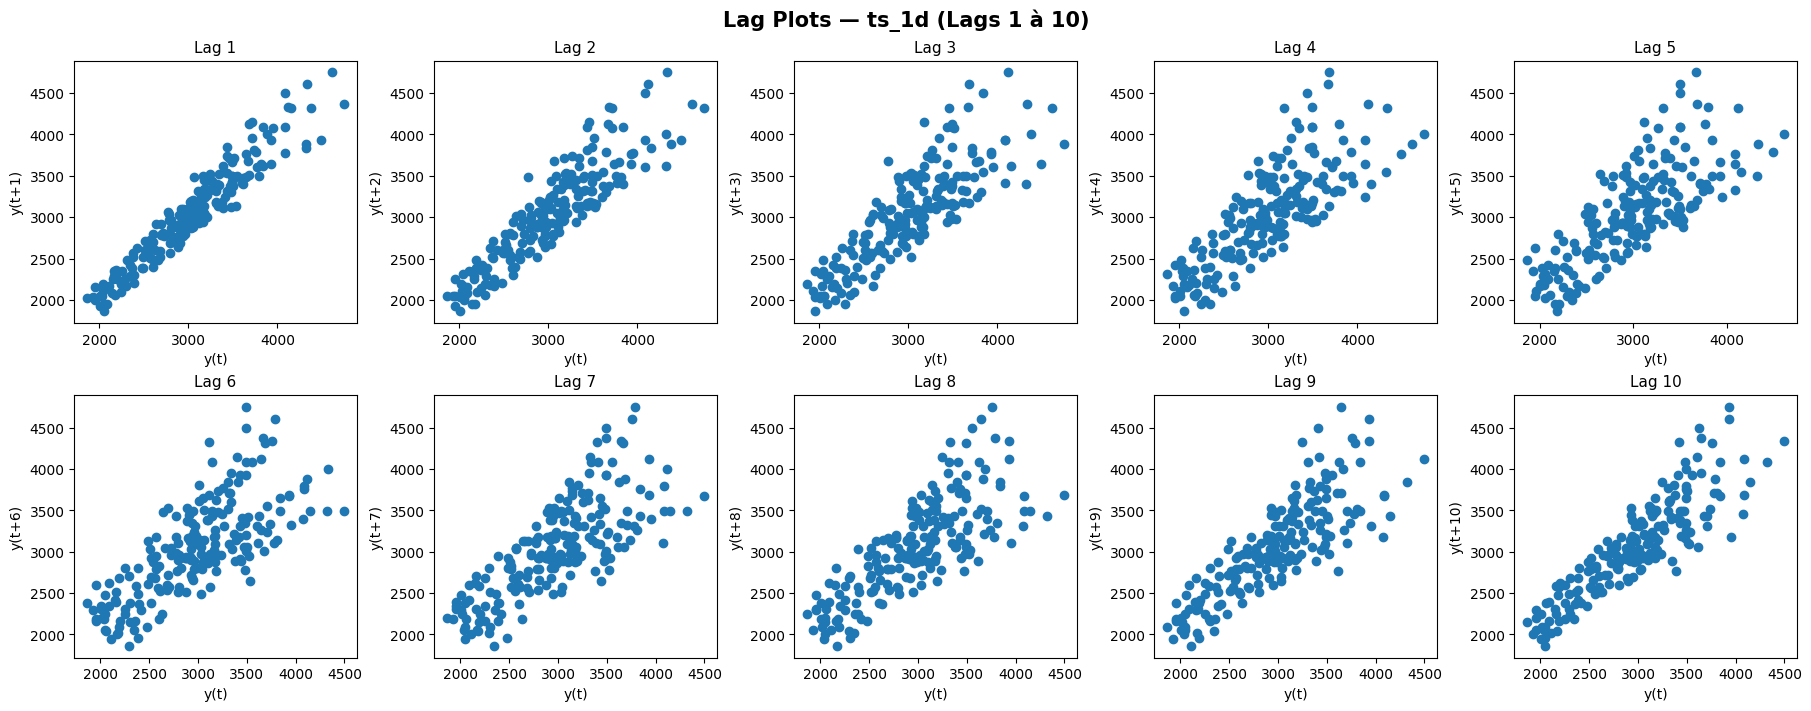

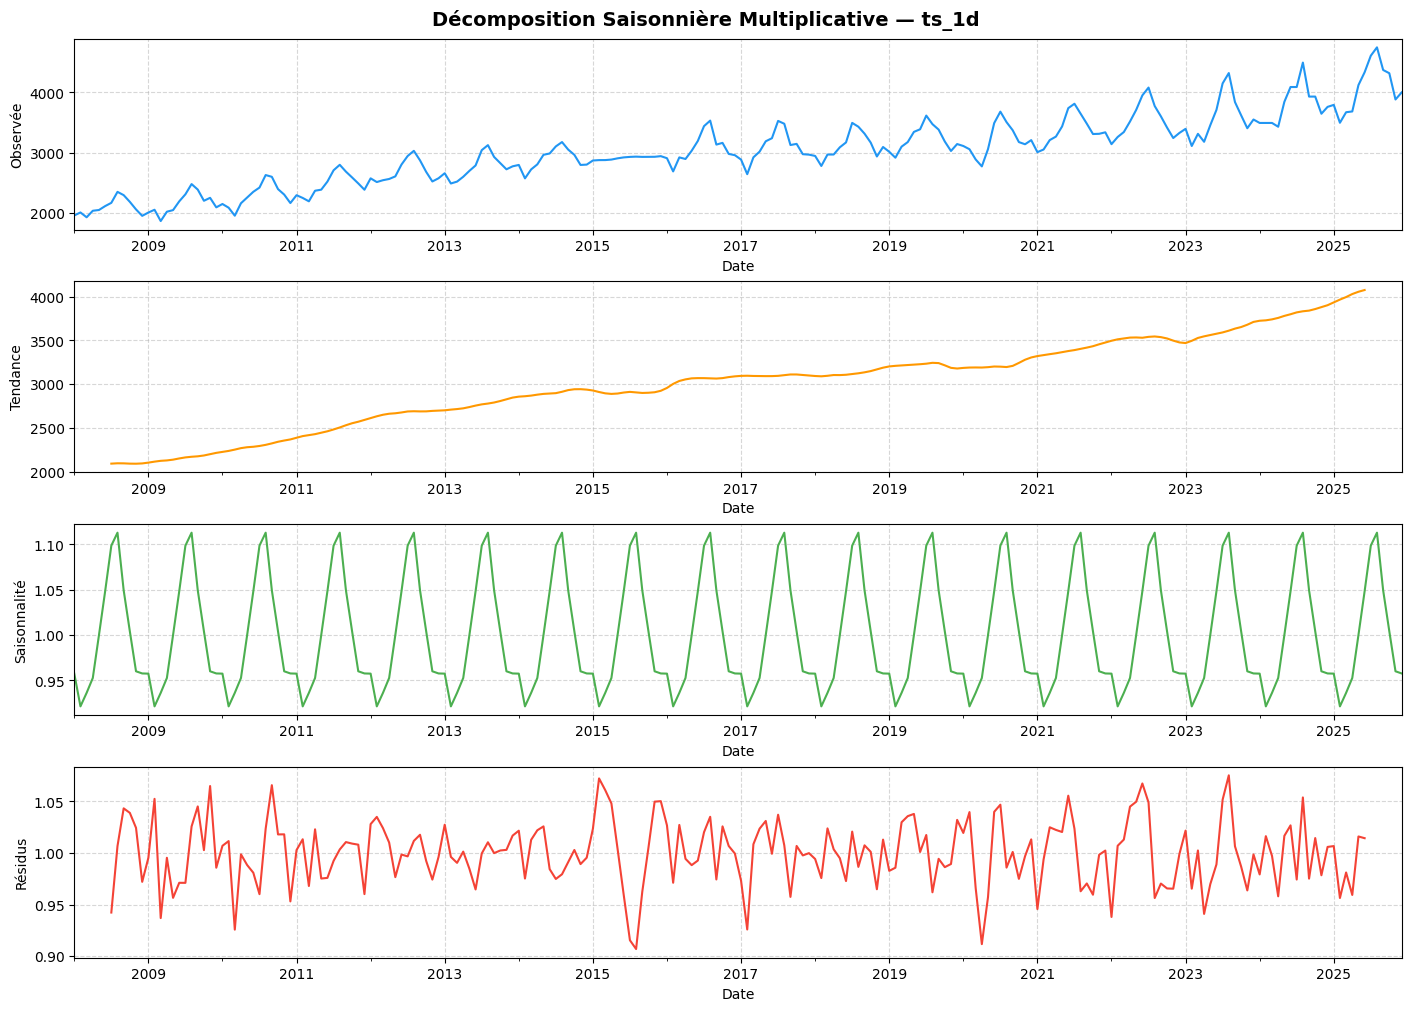

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import lag_plot
from statsmodels.tsa.seasonal import seasonal_decompose

# ============================================================
# 1. LAG PLOTS — Lags 1 à 10
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(18, 7), constrained_layout=True)
fig.suptitle("Lag Plots — ts_1d (Lags 1 à 10)", fontsize=15, fontweight="bold")

for i, ax in enumerate(axes.flatten()):
    lag = i + 1
    lag_plot(ts_1d, lag=lag, ax=ax)
    ax.set_title(f"Lag {lag}", fontsize=11)
    ax.set_xlabel("y(t)")
    ax.set_ylabel(f"y(t+{lag})")

plt.show()

# ============================================================
# 2. DÉCOMPOSITION SAISONNIÈRE MULTIPLICATIVE
# ============================================================
# Le modèle 'multiplicative' requiert impérativement des valeurs > 0.
# Si votre série contient des zéros, remplacez 'multiplicative' par 'additive'.

try:
    decomp = seasonal_decompose(
        ts_1d,
        model="multiplicative",
        # period=12  # <-- Décommentez et ajustez si l'index n'a pas de freq définie
    )

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), constrained_layout=True)
    fig.suptitle("Décomposition Saisonnière Multiplicative — ts_1d",
                 fontsize=14, fontweight="bold")

    decomp.observed.plot(ax=axes[0],  color="#2196F3");  axes[0].set_ylabel("Observée")
    decomp.trend.plot(ax=axes[1],    color="#FF9800");  axes[1].set_ylabel("Tendance")
    decomp.seasonal.plot(ax=axes[2], color="#4CAF50");  axes[2].set_ylabel("Saisonnalité")
    decomp.resid.plot(ax=axes[3],    color="#F44336");  axes[3].set_ylabel("Résidus")

    for ax in axes:
        ax.grid(True, linestyle="--", alpha=0.5)

    plt.show()

except ValueError as e:
    print(f"[ERREUR] {e}")
    print("→ Ajoutez 'period=X' si l'index n'a pas de fréquence, "
          "ou passez à model='additive' si la série contient des valeurs ≤ 0.")


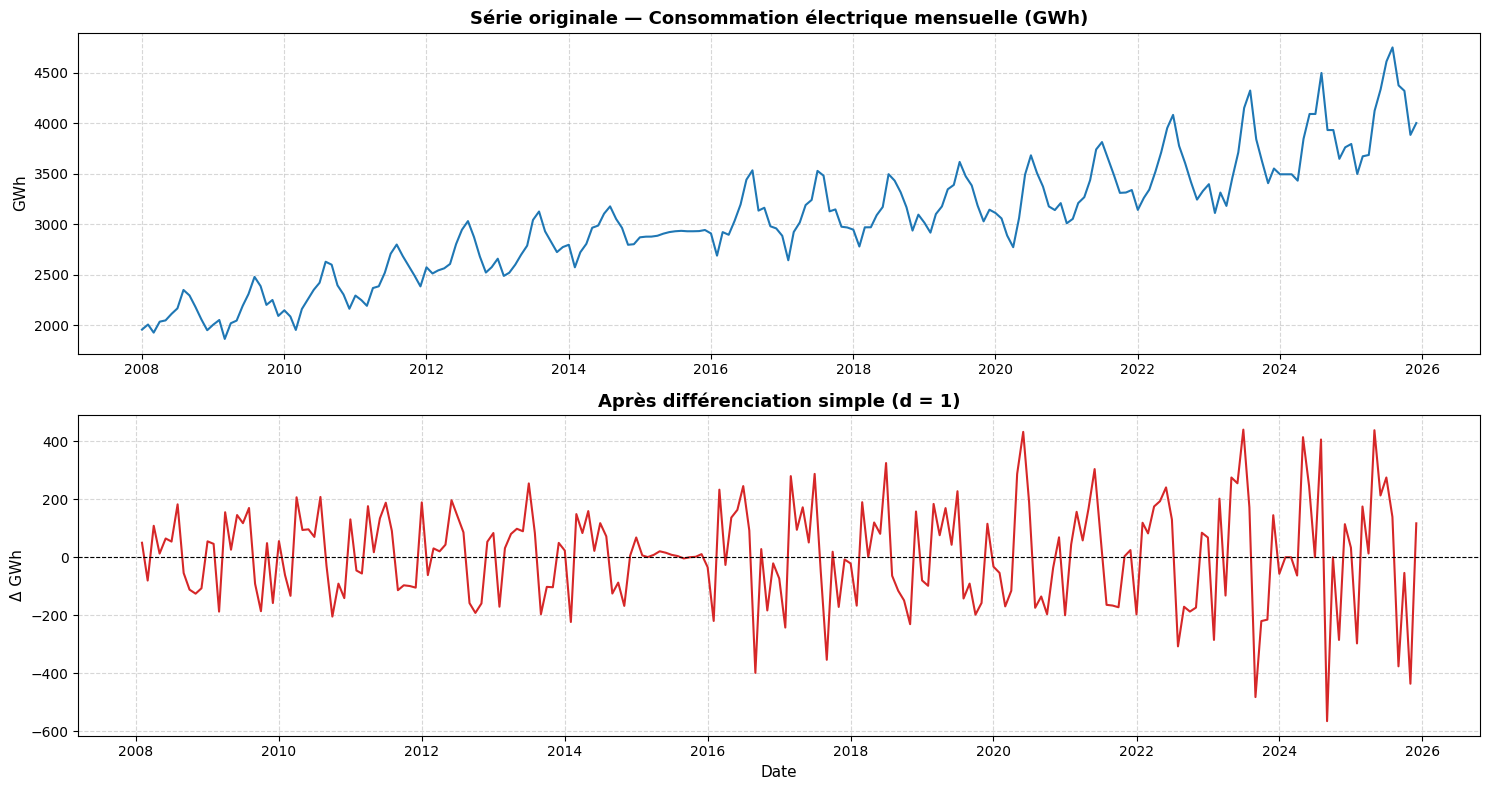

Longueur série originale  : 216
Longueur après diff(1)    : 215
Moyenne diff(1)           : 9.5079
Std    diff(1)            : 170.2964


In [7]:
# ============================================================
# Différenciation simple  (d = 1)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# S'assurer que la série est disponible
series = final_data['Electricity_Consumption'].copy()

# --- Différenciation d'ordre 1 ---
diff1 = series.diff(1).dropna()

# --- Visualisation ---
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Série originale
axes[0].plot(series.index, series.values, color='#1f77b4', linewidth=1.5)
axes[0].set_title('Série originale — Consommation électrique mensuelle (GWh)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('GWh', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Série après différenciation simple
axes[1].plot(diff1.index, diff1.values, color='#d62728', linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Après différenciation simple (d = 1)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Δ GWh', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f'Longueur série originale  : {len(series)}')
print(f'Longueur après diff(1)    : {len(diff1)}')
print(f'Moyenne diff(1)           : {diff1.mean():.4f}')
print(f'Std    diff(1)            : {diff1.std():.4f}')


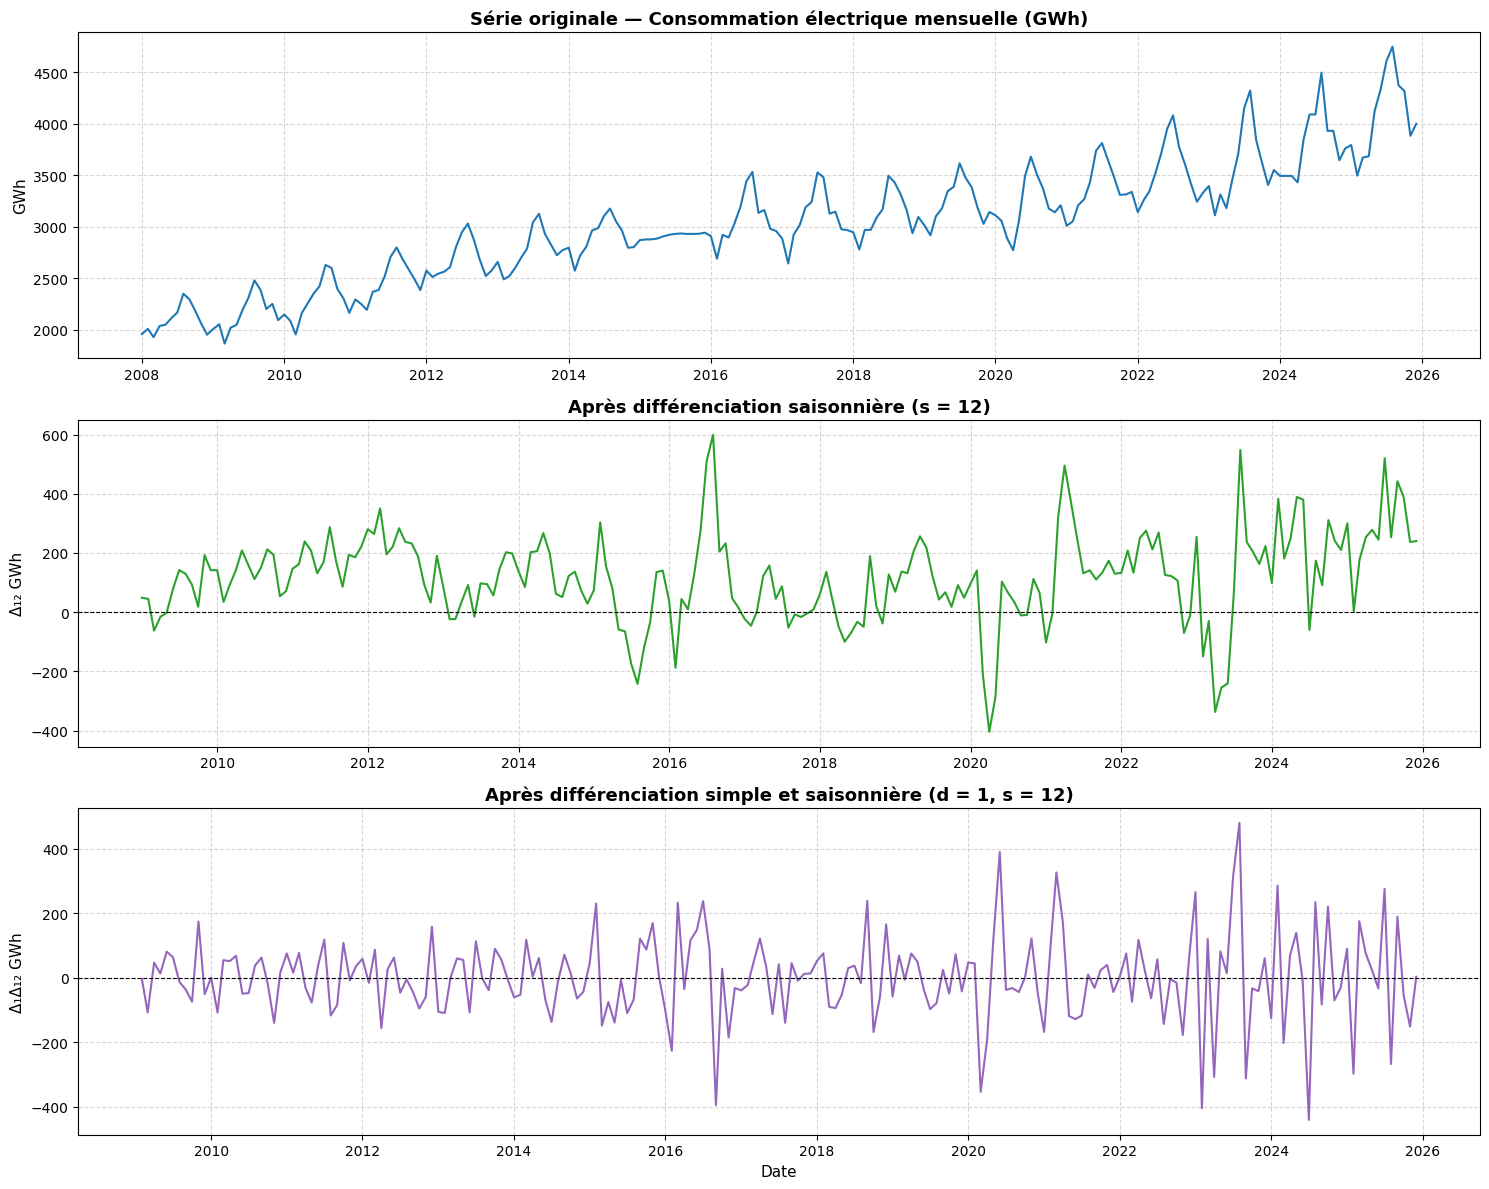


=== Test ADF : Série originale ===
  Statistique ADF : 0.4775
  p-value          : 0.984172
  Valeurs critiques:
    1%: -3.4630
    5%: -2.8759
    10%: -2.5744
  => Série NON STATIONNAIRE (p >= 0.05)

=== Test ADF : Différenciation saisonnière (s=12) ===
  Statistique ADF : -3.3626
  p-value          : 0.012302
  Valeurs critiques:
    1%: -3.4651
    5%: -2.8768
    10%: -2.5749
  => Série STATIONNAIRE (p < 0.05)

=== Test ADF : Différenciation simple + saisonnière (d=1, s=12) ===
  Statistique ADF : -6.3350
  p-value          : 0.000000
  Valeurs critiques:
    1%: -3.4658
    5%: -2.8771
    10%: -2.5751
  => Série STATIONNAIRE (p < 0.05)

Longueur série originale          : 216
Longueur après diff saisonnière   : 204
Longueur après diff(1) + saiso.   : 203


In [8]:
# ============================================================
# Différenciation saisonnière  (d = 1, s = 12)
# i.e. différenciation simple + différenciation saisonnière
# ============================================================
from statsmodels.tsa.stattools import adfuller

series = final_data['Electricity_Consumption'].copy()

# --- Différenciation saisonnière d'ordre 12 (enlève la saisonnalité) ---
diff_s12 = series.diff(12).dropna()

# --- Différenciation simple sur la série déjà différenciée (d=1, s=12) ---
diff1_s12 = diff_s12.diff(1).dropna()

# --- Visualisation ---
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Série originale
axes[0].plot(series.index, series.values, color='#1f77b4', linewidth=1.5)
axes[0].set_title('Série originale — Consommation électrique mensuelle (GWh)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('GWh', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Différenciation saisonnière (s=12)
axes[1].plot(diff_s12.index, diff_s12.values, color='#2ca02c', linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Après différenciation saisonnière (s = 12)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Δ₁₂ GWh', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Différenciation simple + saisonnière (d=1, s=12)
axes[2].plot(diff1_s12.index, diff1_s12.values, color='#9467bd', linewidth=1.5)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Après différenciation simple et saisonnière (d = 1, s = 12)',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Δ₁Δ₁₂ GWh', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# --- Test ADF pour vérifier la stationnarité ---
def adf_test(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'\n=== Test ADF : {label} ===')
    print(f'  Statistique ADF : {result[0]:.4f}')
    print(f'  p-value          : {result[1]:.6f}')
    print(f'  Valeurs critiques:')
    for key, val in result[4].items():
        print(f'    {key}: {val:.4f}')
    if result[1] < 0.05:
        print('  => Série STATIONNAIRE (p < 0.05)')
    else:
        print('  => Série NON STATIONNAIRE (p >= 0.05)')

adf_test(series,    'Série originale')
adf_test(diff_s12,  'Différenciation saisonnière (s=12)')
adf_test(diff1_s12, 'Différenciation simple + saisonnière (d=1, s=12)')

print(f'\nLongueur série originale          : {len(series)}')
print(f'Longueur après diff saisonnière   : {len(diff_s12)}')
print(f'Longueur après diff(1) + saiso.   : {len(diff1_s12)}')


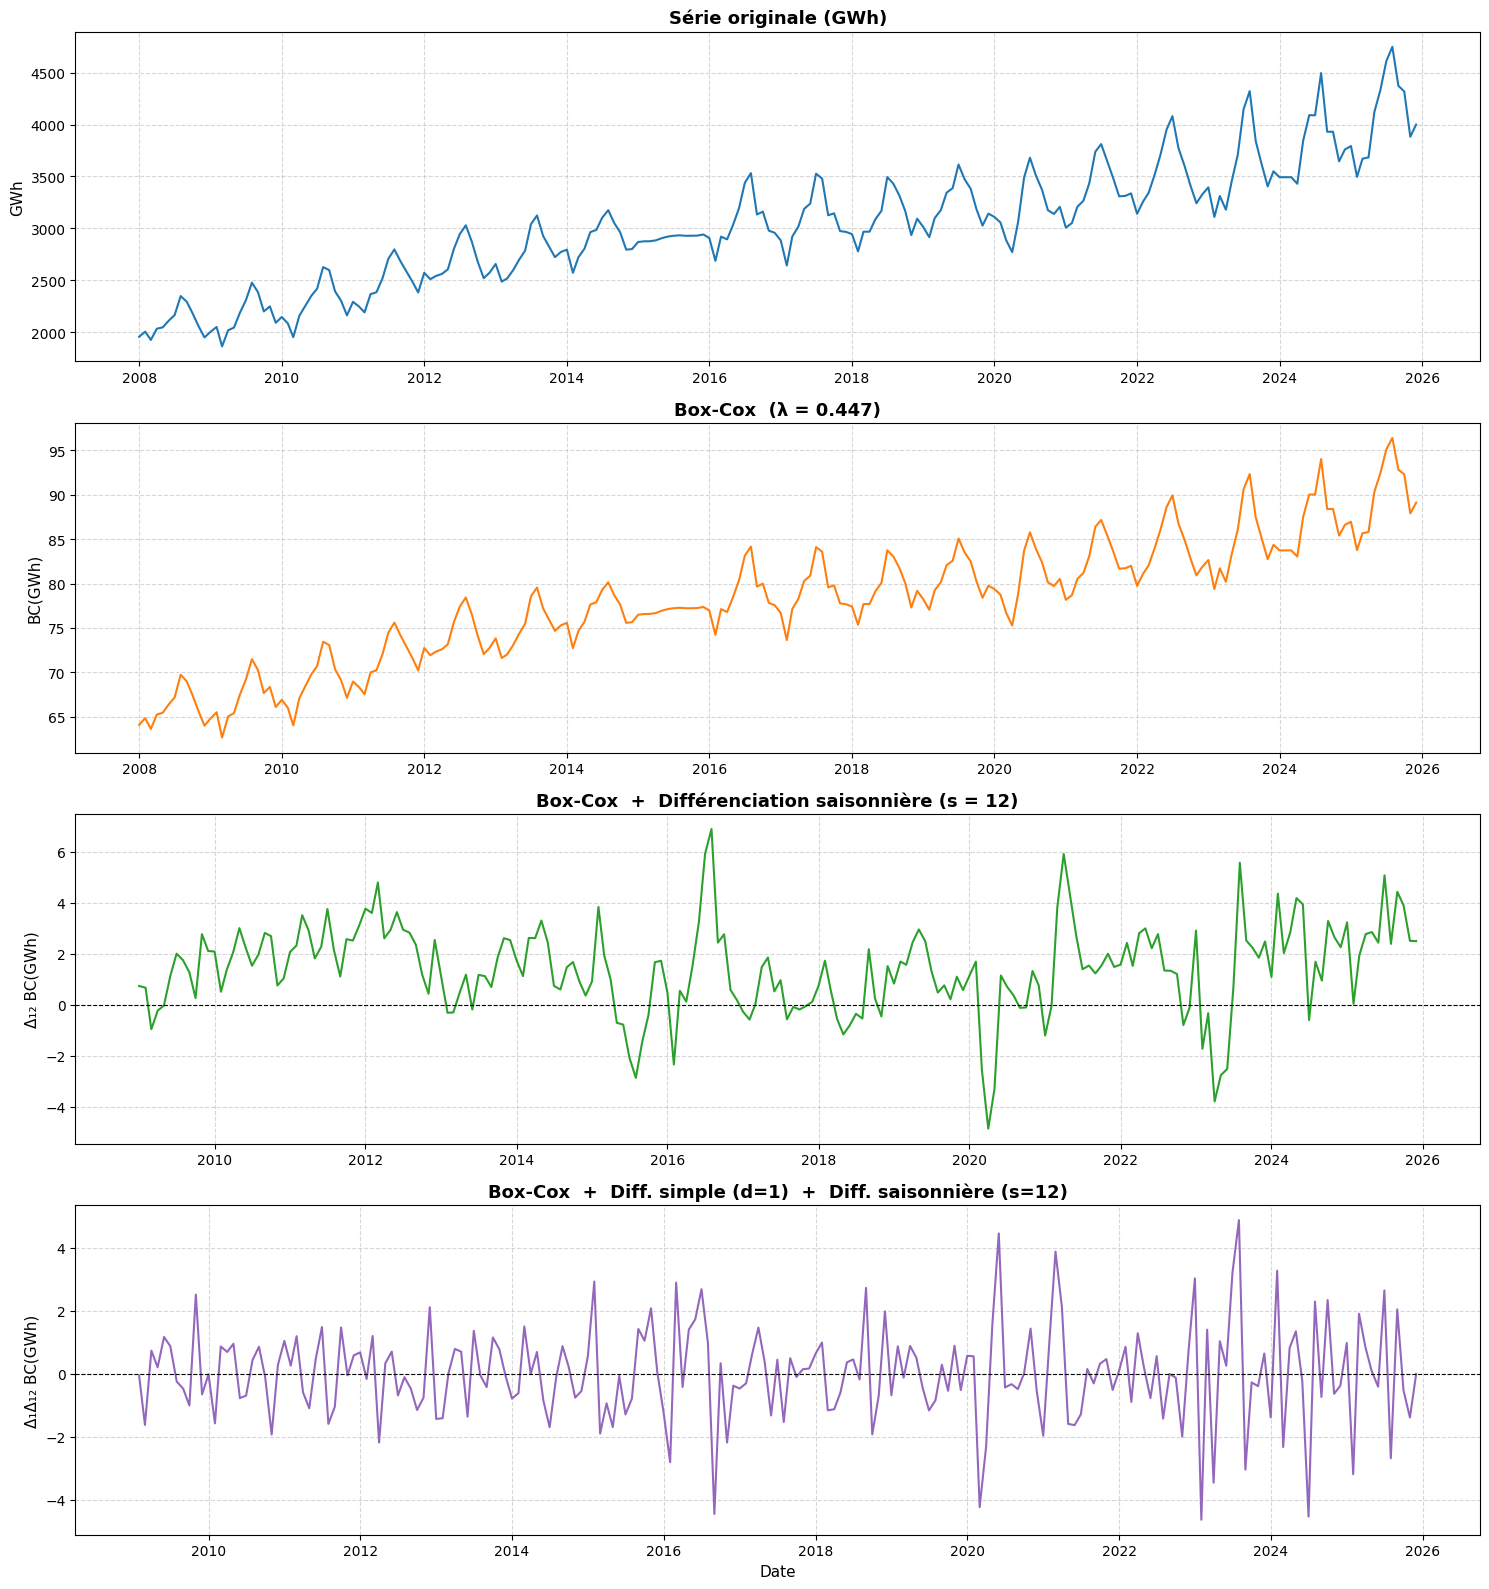


=== ADF : Série originale ===
  Stat ADF : 0.4775   |   p-value : 0.984172
    Valeur critique 1%: -3.4630
    Valeur critique 5%: -2.8759
    Valeur critique 10%: -2.5744
  => NON STATIONNAIRE

=== ADF : Box-Cox ===
  Stat ADF : -0.3188   |   p-value : 0.922792
    Valeur critique 1%: -3.4630
    Valeur critique 5%: -2.8759
    Valeur critique 10%: -2.5744
  => NON STATIONNAIRE

=== ADF : Box-Cox + diff saisonnière (s=12) ===
  Stat ADF : -3.5047   |   p-value : 0.007867
    Valeur critique 1%: -3.4651
    Valeur critique 5%: -2.8768
    Valeur critique 10%: -2.5749
  => STATIONNAIRE

=== ADF : Box-Cox + diff(1) + diff saisonnière (s=12) ===
  Stat ADF : -6.3559   |   p-value : 0.000000
    Valeur critique 1%: -3.4658
    Valeur critique 5%: -2.8771
    Valeur critique 10%: -2.5751
  => STATIONNAIRE

Longueurs :
  Originale                   : 216
  Après Box-Cox + diff(s=12)  : 204
  Après Box-Cox + d=1 + s=12  : 203


In [9]:
# ============================================================
# Transformation Box-Cox  +  Différenciation saisonnière
# (différenciation simple d=1  +  saisonnière s=12)
# ============================================================
from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import pandas as pd

series = final_data['Electricity_Consumption'].copy()

# ── Transformation Box-Cox ────────────────────────────────────
series_bc, lambda_opt = boxcox(series)
series_bc = pd.Series(series_bc, index=series.index)

# ── Différenciation saisonnière (s=12) ────────────────────────
diff_s12_bc = series_bc.diff(12).dropna()

# ── Différenciation simple (d=1) sur la série déjà diff. ─────
diff1_s12_bc = diff_s12_bc.diff(1).dropna()

# ── Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(15, 16))

axes[0].plot(series.index, series.values, color='#1f77b4', linewidth=1.5)
axes[0].set_title('Série originale (GWh)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('GWh', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(series_bc.index, series_bc.values, color='#ff7f0e', linewidth=1.5)
axes[1].set_title(f'Box-Cox  (λ = {lambda_opt:.3f})', fontsize=13, fontweight='bold')
axes[1].set_ylabel('BC(GWh)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].plot(diff_s12_bc.index, diff_s12_bc.values, color='#2ca02c', linewidth=1.5)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Box-Cox  +  Différenciation saisonnière (s = 12)',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Δ₁₂ BC(GWh)', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.5)

axes[3].plot(diff1_s12_bc.index, diff1_s12_bc.values, color='#9467bd', linewidth=1.5)
axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[3].set_title('Box-Cox  +  Diff. simple (d=1)  +  Diff. saisonnière (s=12)',
                  fontsize=13, fontweight='bold')
axes[3].set_ylabel('Δ₁Δ₁₂ BC(GWh)', fontsize=11)
axes[3].set_xlabel('Date', fontsize=11)
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ── Tests ADF ─────────────────────────────────────────────────
def adf_test(s, label):
    result = adfuller(s.dropna(), autolag='AIC')
    p = result[1]
    print(f"\n=== ADF : {label} ===")
    print(f"  Stat ADF : {result[0]:.4f}   |   p-value : {p:.6f}")
    for k, v in result[4].items():
        print(f"    Valeur critique {k}: {v:.4f}")
    print("  => STATIONNAIRE" if p < 0.05 else "  => NON STATIONNAIRE")

adf_test(series,        "Série originale")
adf_test(series_bc,     "Box-Cox")
adf_test(diff_s12_bc,   "Box-Cox + diff saisonnière (s=12)")
adf_test(diff1_s12_bc,  "Box-Cox + diff(1) + diff saisonnière (s=12)")

print(f"\nLongueurs :")
print(f"  Originale                   : {len(series)}")
print(f"  Après Box-Cox + diff(s=12)  : {len(diff_s12_bc)}")
print(f"  Après Box-Cox + d=1 + s=12  : {len(diff1_s12_bc)}")


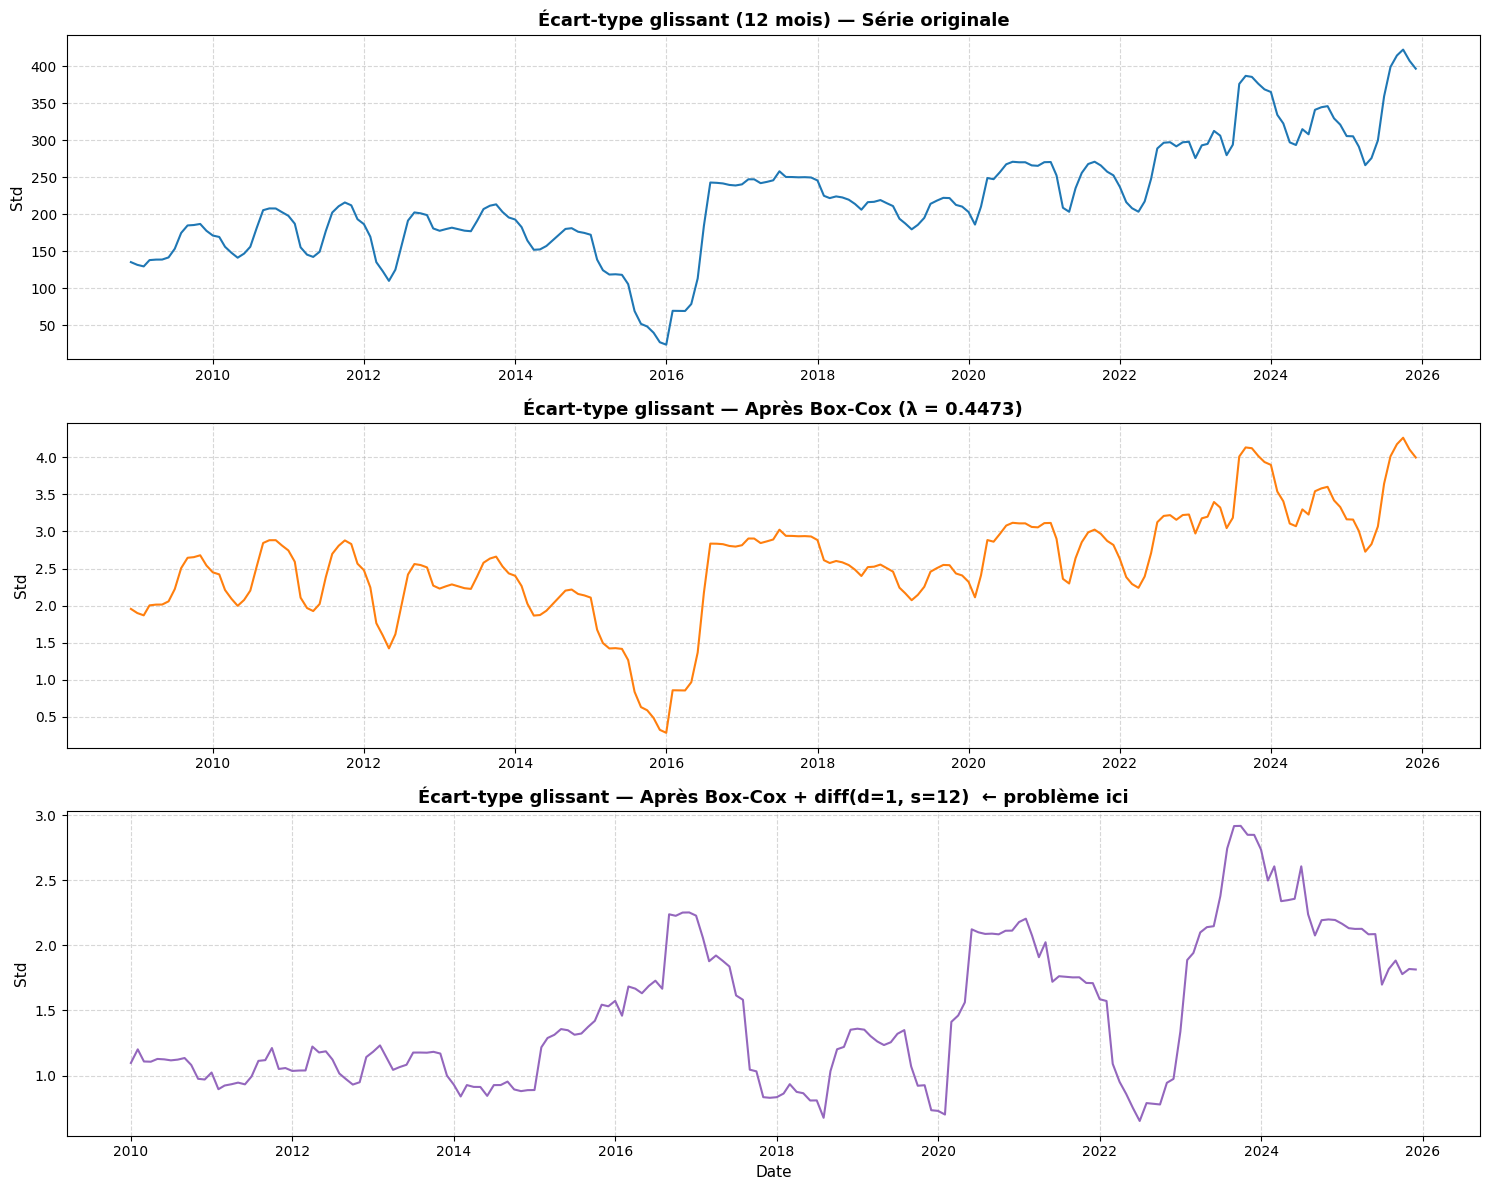

Lambda Box-Cox : 0.4473
=> Si λ proche de 1, Box-Cox = pas de transformation !
=> Si λ proche de 0, Box-Cox ≈ log-transformation


In [10]:
# ============================================================
# Diagnostic : Variance croissante dans le temps
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import boxcox

series = final_data['Electricity_Consumption'].copy()

# Box-Cox avec lambda optimal
series_bc, lambda_opt = boxcox(series)
series_bc = pd.Series(series_bc, index=series.index)

# Transformation finale (diff d=1, s=12)
diff_final = series_bc.diff(12).diff(1).dropna()

# ── Calcul de la variance glissante (fenêtre = 12 mois) ──────
roll_std_original  = series.rolling(window=12).std()
roll_std_bc        = series_bc.rolling(window=12).std()
roll_std_diff_final = diff_final.rolling(window=12).std()

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

axes[0].plot(series.index, roll_std_original, color='#1f77b4', linewidth=1.5)
axes[0].set_title('Écart-type glissant (12 mois) — Série originale',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Std', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(series_bc.index, roll_std_bc, color='#ff7f0e', linewidth=1.5)
axes[1].set_title(f'Écart-type glissant — Après Box-Cox (λ = {lambda_opt:.4f})',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Std', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].plot(diff_final.index, roll_std_diff_final, color='#9467bd', linewidth=1.5)
axes[2].set_title('Écart-type glissant — Après Box-Cox + diff(d=1, s=12)  ← problème ici',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Std', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Lambda Box-Cox : {lambda_opt:.4f}")
print("=> Si λ proche de 1, Box-Cox = pas de transformation !")
print("=> Si λ proche de 0, Box-Cox ≈ log-transformation")


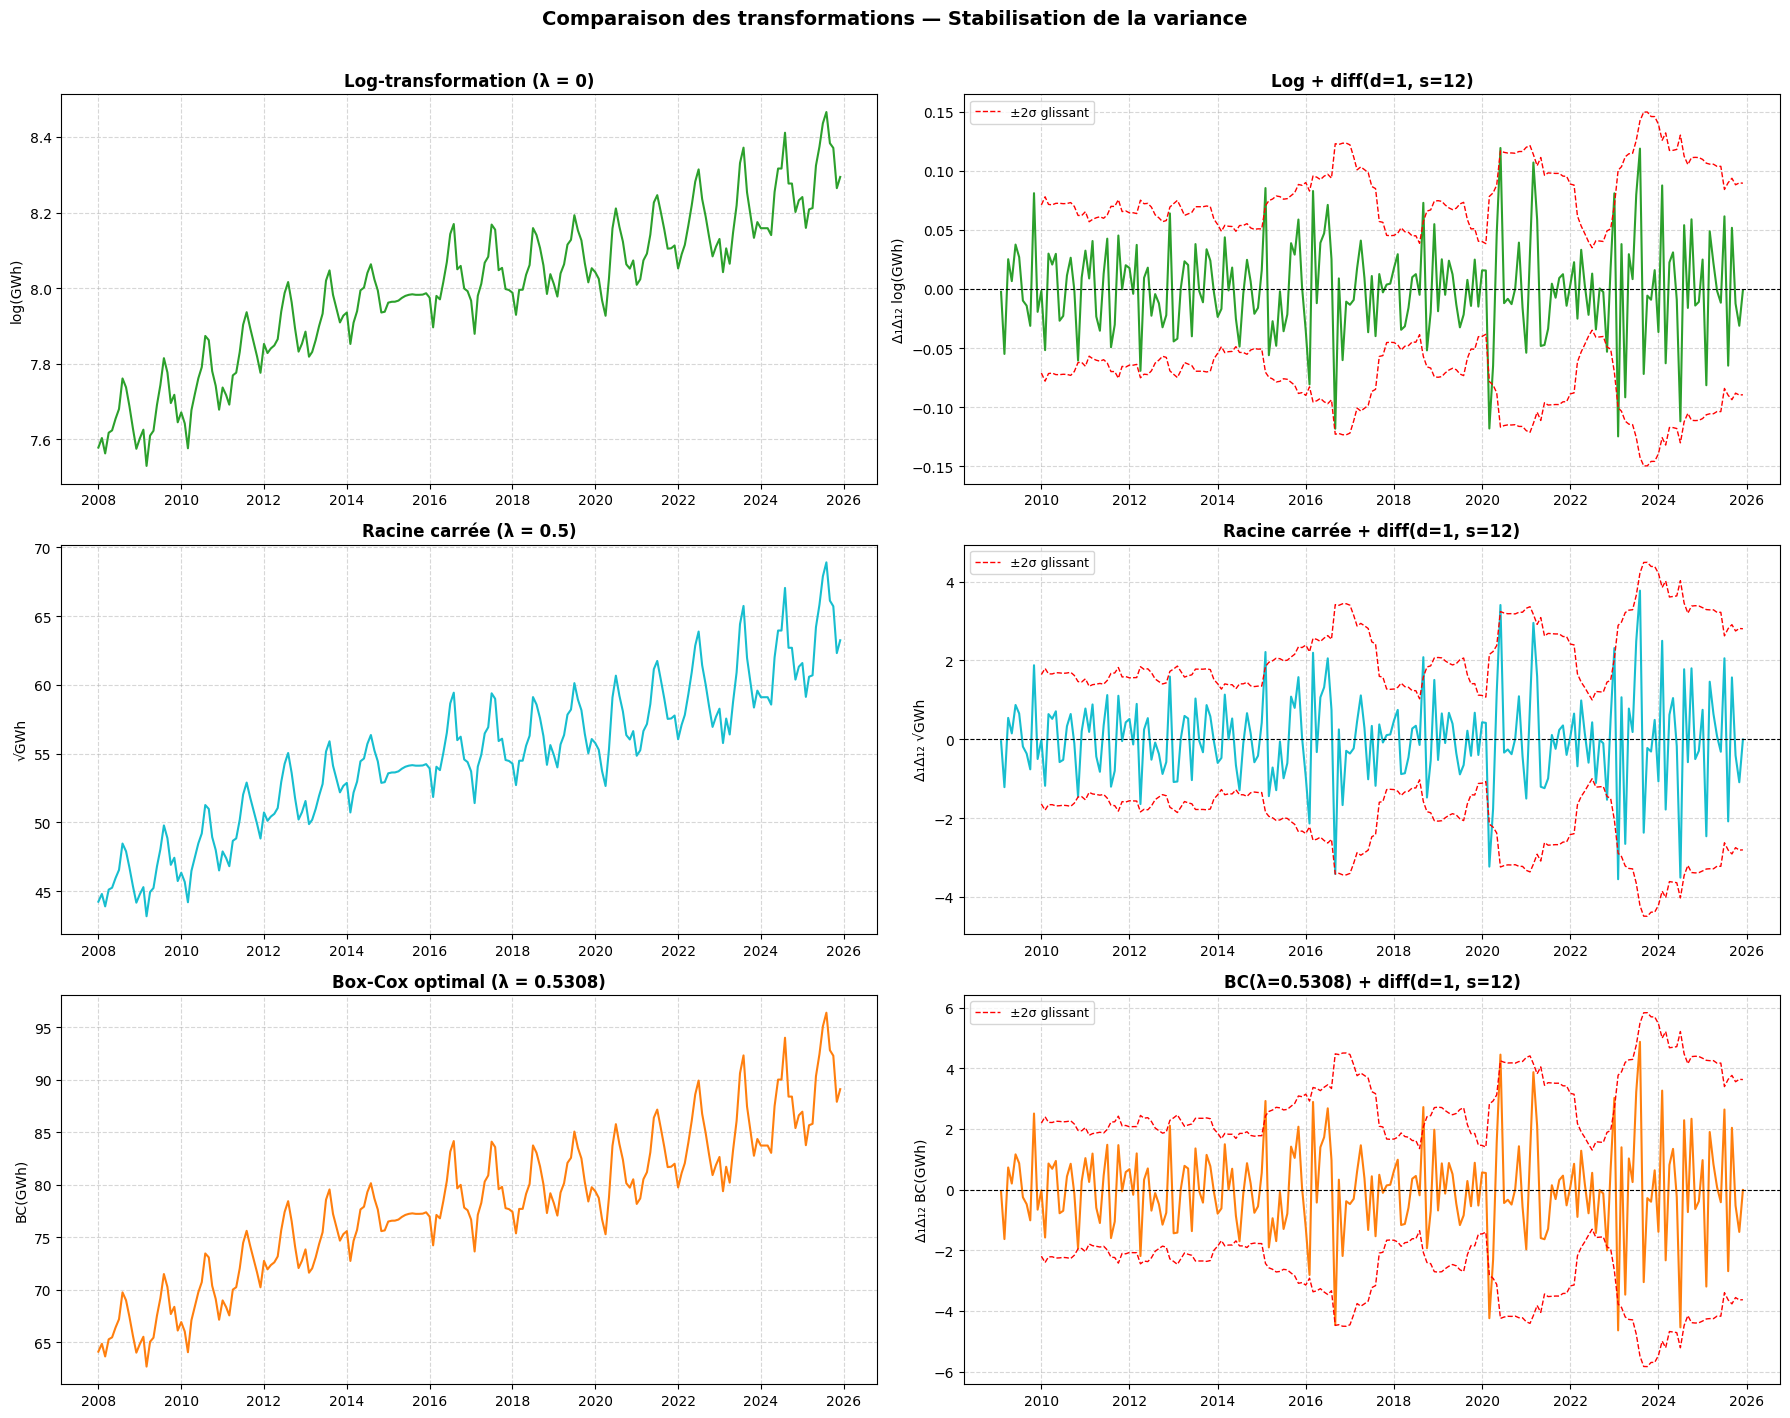

COMPARAISON : Std 1ère moitié vs Std 2ème moitié
(Idéal : les deux valeurs proches = variance constante)

Log + diff(d=1,s=12)
  Std 1ère moitié : 0.0367
  Std 2ème moitié : 0.0452
  Ratio (2/1)     : 1.2324  ✓ OK

Sqrt + diff(d=1,s=12)
  Std 1ère moitié : 0.9522
  Std 2ème moitié : 1.3235
  Ratio (2/1)     : 1.3899  ✗ Variance instable

BC(λ=0.531) + diff(d=1,s=12)
  Std 1ère moitié : 1.2555
  Std 2ème moitié : 1.7234
  Ratio (2/1)     : 1.3727  ✗ Variance instable

TEST ADF sur la meilleure transformation (log + diff)
Stat ADF  : -6.3434
p-value   : 0.000000
  Critique 1%: -3.4658
  Critique 5%: -2.8771
  Critique 10%: -2.5751
=> STATIONNAIRE


In [11]:
# ============================================================
# Solution : Log-transformation (λ=0) + diff(d=1, s=12)
# + Comparaison avec Box-Cox optimal
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import boxcox, boxcox_normmax
from statsmodels.tsa.stattools import adfuller

series = final_data['Electricity_Consumption'].copy()

# ── Différentes transformations ───────────────────────────────
lambda_opt  = boxcox_normmax(series)         # lambda optimal
series_log  = np.log(series)                 # log = Box-Cox avec λ=0
series_sqrt = np.sqrt(series)                # racine = Box-Cox avec λ=0.5
series_bc   = pd.Series(boxcox(series)[0], index=series.index)

series_log  = pd.Series(series_log.values,  index=series.index)
series_sqrt = pd.Series(series_sqrt.values, index=series.index)

# ── Différenciation d=1 + s=12 sur chaque transformation ─────
diff_log   = series_log.diff(12).diff(1).dropna()
diff_sqrt  = series_sqrt.diff(12).diff(1).dropna()
diff_bc    = series_bc.diff(12).diff(1).dropna()

# ── Variance glissante (12 mois) pour comparer ───────────────
def rolling_cv(s, window=12):
    """Coefficient de variation glissant = std/|mean|  (normalisé)"""
    r_std  = s.rolling(window).std()
    r_mean = s.rolling(window).mean().abs()
    return (r_std / r_mean).replace([np.inf, -np.inf], np.nan)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# Ligne 1 : log-transformation
axes[0, 0].plot(series_log.index, series_log.values, color='#2ca02c', linewidth=1.5)
axes[0, 0].set_title('Log-transformation (λ = 0)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('log(GWh)', fontsize=10)
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

axes[0, 1].plot(diff_log.index, diff_log.values, color='#2ca02c', linewidth=1.5)
axes[0, 1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0, 1].plot(diff_log.index, diff_log.rolling(12).std() * 2,
                color='red', linewidth=1, linestyle='--', label='±2σ glissant')
axes[0, 1].plot(diff_log.index, -diff_log.rolling(12).std() * 2,
                color='red', linewidth=1, linestyle='--')
axes[0, 1].set_title('Log + diff(d=1, s=12)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Δ₁Δ₁₂ log(GWh)', fontsize=10)
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Ligne 2 : racine carrée
axes[1, 0].plot(series_sqrt.index, series_sqrt.values, color='#17becf', linewidth=1.5)
axes[1, 0].set_title('Racine carrée (λ = 0.5)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('√GWh', fontsize=10)
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

axes[1, 1].plot(diff_sqrt.index, diff_sqrt.values, color='#17becf', linewidth=1.5)
axes[1, 1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1, 1].plot(diff_sqrt.index, diff_sqrt.rolling(12).std() * 2,
                color='red', linewidth=1, linestyle='--', label='±2σ glissant')
axes[1, 1].plot(diff_sqrt.index, -diff_sqrt.rolling(12).std() * 2,
                color='red', linewidth=1, linestyle='--')
axes[1, 1].set_title('Racine carrée + diff(d=1, s=12)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Δ₁Δ₁₂ √GWh', fontsize=10)
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

# Ligne 3 : Box-Cox optimal
axes[2, 0].plot(series_bc.index, series_bc.values, color='#ff7f0e', linewidth=1.5)
axes[2, 0].set_title(f'Box-Cox optimal (λ = {lambda_opt:.4f})', fontsize=12, fontweight='bold')
axes[2, 0].set_ylabel('BC(GWh)', fontsize=10)
axes[2, 0].grid(True, linestyle='--', alpha=0.5)

axes[2, 1].plot(diff_bc.index, diff_bc.values, color='#ff7f0e', linewidth=1.5)
axes[2, 1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2, 1].plot(diff_bc.index, diff_bc.rolling(12).std() * 2,
                color='red', linewidth=1, linestyle='--', label='±2σ glissant')
axes[2, 1].plot(diff_bc.index, -diff_bc.rolling(12).std() * 2,
                color='red', linewidth=1, linestyle='--')
axes[2, 1].set_title(f'BC(λ={lambda_opt:.4f}) + diff(d=1, s=12)', fontsize=12, fontweight='bold')
axes[2, 1].set_ylabel('Δ₁Δ₁₂ BC(GWh)', fontsize=10)
axes[2, 1].legend(fontsize=9)
axes[2, 1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Comparaison des transformations — Stabilisation de la variance',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Résumé numérique : std dans la 1ère moitié vs 2ème moitié ─
print("=" * 60)
print("COMPARAISON : Std 1ère moitié vs Std 2ème moitié")
print("(Idéal : les deux valeurs proches = variance constante)")
print("=" * 60)

for label, s in [("Log + diff(d=1,s=12)",   diff_log),
                 ("Sqrt + diff(d=1,s=12)",  diff_sqrt),
                 (f"BC(λ={lambda_opt:.3f}) + diff(d=1,s=12)", diff_bc)]:
    mid = len(s) // 2
    std1 = s.iloc[:mid].std()
    std2 = s.iloc[mid:].std()
    ratio = std2 / std1
    print(f"\n{label}")
    print(f"  Std 1ère moitié : {std1:.4f}")
    print(f"  Std 2ème moitié : {std2:.4f}")
    print(f"  Ratio (2/1)     : {ratio:.4f}  {'✓ OK' if abs(ratio-1) < 0.3 else '✗ Variance instable'}")

# ── Test ADF sur la meilleure transformation ───────────────────
print("\n" + "=" * 60)
print("TEST ADF sur la meilleure transformation (log + diff)")
print("=" * 60)
result = adfuller(diff_log.dropna(), autolag='AIC')
print(f"Stat ADF  : {result[0]:.4f}")
print(f"p-value   : {result[1]:.6f}")
for k, v in result[4].items():
    print(f"  Critique {k}: {v:.4f}")
print("=> STATIONNAIRE" if result[1] < 0.05 else "=> NON STATIONNAIRE")



ADF [Log] : stat=-0.9561, p=0.768925 => NON STATIONNAIRE ✗

ADF [Log + diff saisonnière (s=12)] : stat=-3.4787, p=0.008552 => STATIONNAIRE ✓

ADF [Log + diff(d=1, s=12)] : stat=-6.3434, p=0.000000 => STATIONNAIRE ✓


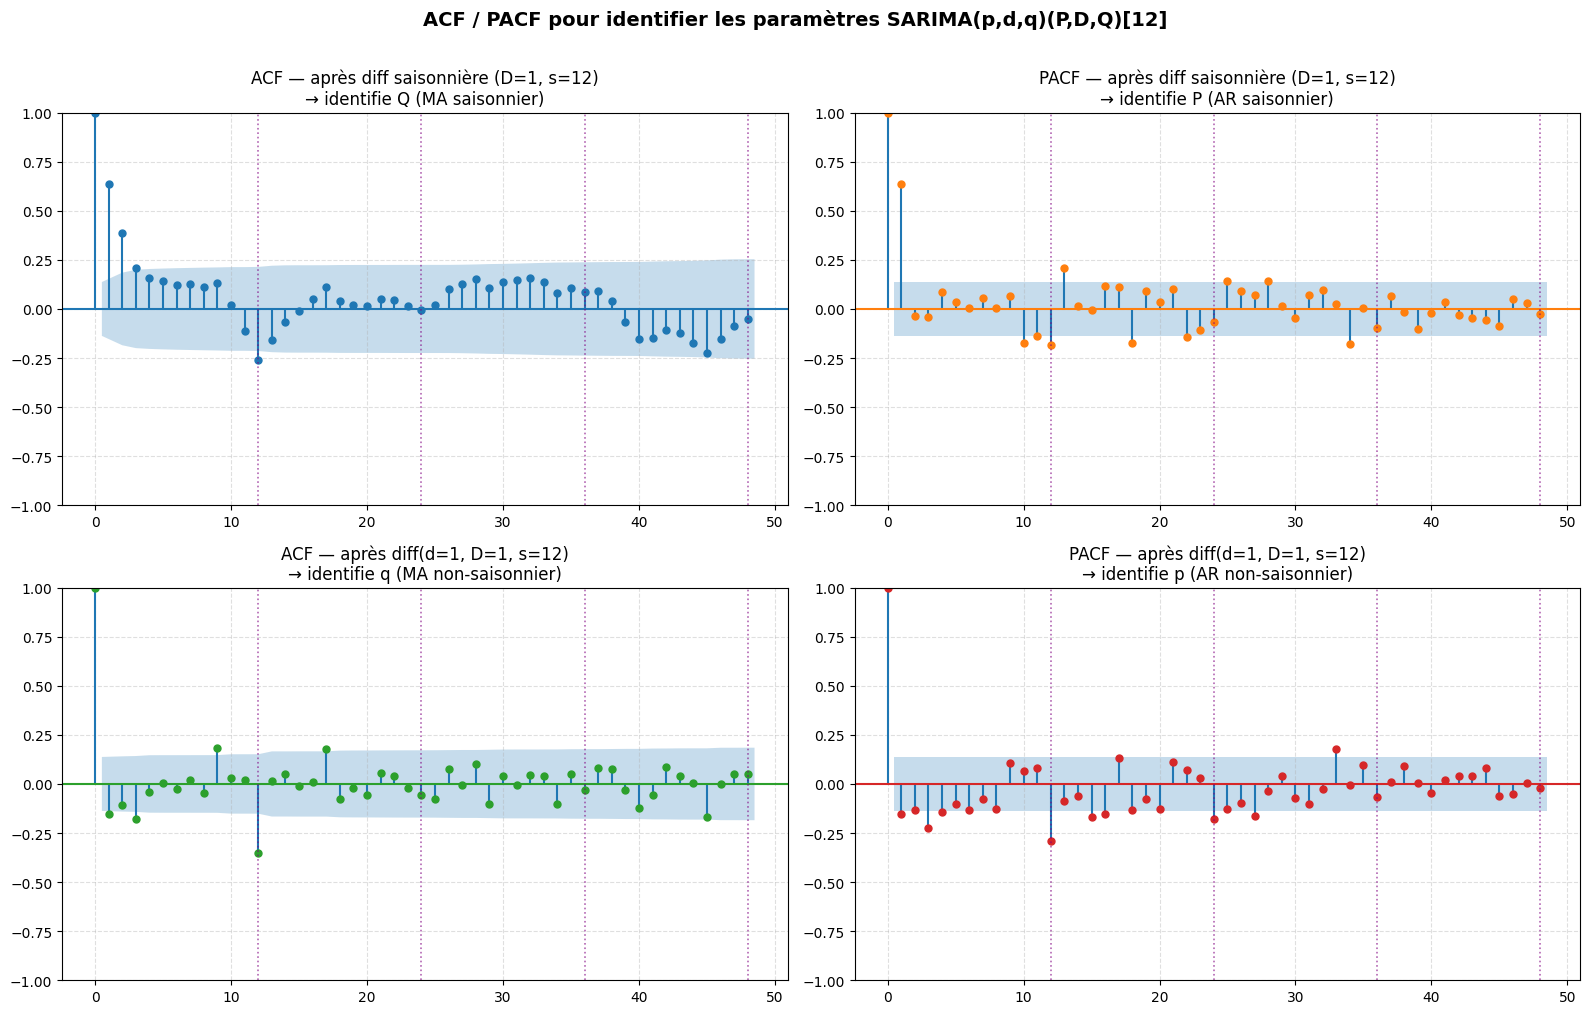


📖 Guide de lecture :
  ACF  coupe à lag q  → ordre q (MA)
  PACF coupe à lag p  → ordre p (AR)
  Aux lags saisonniers (12,24,...) : même logique pour P et Q


In [12]:
# ============================================================
# SARIMA — Étape 1 : Identification des paramètres
#          via ACF et PACF sur la série transformée
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox, boxcox_normmax
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

series = final_data['Electricity_Consumption'].copy()

# ── Transformation log pour stabiliser la variance ───────────
series_log = np.log(series)
series_log = pd.Series(series_log.values, index=series.index)

# ── Différenciation saisonnière (s=12) + simple (d=1) ────────
diff_log_s12 = series_log.diff(12).dropna()   # différenciation saisonnière
diff_log_1_s12 = diff_log_s12.diff(1).dropna()  # + différenciation simple

# ── Test ADF pour confirmer la stationnarité ─────────────────
def adf_test(s, label):
    r = adfuller(s.dropna(), autolag='AIC')
    print(f"\nADF [{label}] : stat={r[0]:.4f}, p={r[1]:.6f}",
          "=> STATIONNAIRE ✓" if r[1] < 0.05 else "=> NON STATIONNAIRE ✗")

adf_test(series_log,       "Log")
adf_test(diff_log_s12,     "Log + diff saisonnière (s=12)")
adf_test(diff_log_1_s12,   "Log + diff(d=1, s=12)")

# ── ACF et PACF pour identifier p, q, P, Q ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sur la série après diff saisonnière seulement → P et Q
plot_acf(diff_log_s12.dropna(),  lags=48, ax=axes[0, 0],
         title='ACF — après diff saisonnière (D=1, s=12)\n→ identifie Q (MA saisonnier)',
         color='#1f77b4')
plot_pacf(diff_log_s12.dropna(), lags=48, ax=axes[0, 1], method='ywm',
          title='PACF — après diff saisonnière (D=1, s=12)\n→ identifie P (AR saisonnier)',
          color='#ff7f0e')

# Sur la série après diff saisonnière + simple → p et q
plot_acf(diff_log_1_s12.dropna(),  lags=48, ax=axes[1, 0],
         title='ACF — après diff(d=1, D=1, s=12)\n→ identifie q (MA non-saisonnier)',
         color='#2ca02c')
plot_pacf(diff_log_1_s12.dropna(), lags=48, ax=axes[1, 1], method='ywm',
          title='PACF — après diff(d=1, D=1, s=12)\n→ identifie p (AR non-saisonnier)',
          color='#d62728')

# Marquer les retards saisonniers (12, 24, 36, 48)
for ax in axes.flat:
    for lag in [12, 24, 36, 48]:
        ax.axvline(lag, color='purple', linestyle=':', linewidth=1.2, alpha=0.6)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("ACF / PACF pour identifier les paramètres SARIMA(p,d,q)(P,D,Q)[12]",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📖 Guide de lecture :")
print("  ACF  coupe à lag q  → ordre q (MA)")
print("  PACF coupe à lag p  → ordre p (AR)")
print("  Aux lags saisonniers (12,24,...) : même logique pour P et Q")


In [13]:
# ============================================================
# SARIMA — Étape 2 : Sélection automatique + Ajustement
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.stats import boxcox
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools

series = final_data['Electricity_Consumption'].copy()
series_log = np.log(series)
series_log = pd.Series(series_log.values, index=series.index)

# ── Split Train / Test (80% / 20%) ───────────────────────────
n_test  = 24   # 24 mois = 2 ans de test
train   = series_log.iloc[:-n_test]
test    = series_log.iloc[-n_test:]

print(f"Train : {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} obs.)")
print(f"Test  : {test.index[0].date()}  → {test.index[-1].date()}   ({len(test)} obs.)")

# ── Grille de recherche des paramètres ───────────────────────
# Basée sur l'ACF/PACF de la cellule précédente
p_range = range(0, 3)   # AR non-saisonnier
q_range = range(0, 3)   # MA non-saisonnier
P_range = range(0, 2)   # AR saisonnier
Q_range = range(0, 2)   # MA saisonnier
d, D, s = 1, 1, 12

results = []
total = len(list(itertools.product(p_range, q_range, P_range, Q_range)))
print(f"\n🔍 Recherche sur {total} combinaisons SARIMA...\n")

best_aic = np.inf
best_params = None

for i, (p, q, P, Q) in enumerate(itertools.product(p_range, q_range, P_range, Q_range)):
    try:
        model = SARIMAX(train,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        fit = model.fit(disp=False)
        results.append({
            'order': (p, d, q),
            'seasonal_order': (P, D, Q, s),
            'AIC': round(fit.aic, 2),
            'BIC': round(fit.bic, 2)
        })
        if fit.aic < best_aic:
            best_aic    = fit.aic
            best_params = (p, d, q, P, D, Q)
    except Exception:
        pass

# Afficher les 10 meilleurs modèles
df_results = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
print("🏆 Top 10 modèles SARIMA (tri par AIC) :")
print(df_results.head(10).to_string(index=False))

# ── Ajuster le meilleur modèle ───────────────────────────────
p, d, q, P, D, Q = best_params
print(f"\n✅ Meilleur modèle : SARIMA({p},{d},{q})({P},{D},{Q})[{s}]  AIC={best_aic:.2f}")

best_model = SARIMAX(train,
                     order=(p, d, q),
                     seasonal_order=(P, D, Q, s),
                     enforce_stationarity=False,
                     enforce_invertibility=False)
best_fit = best_model.fit(disp=False)

print("\n" + "=" * 60)
print(best_fit.summary())


Train : 2008-01-01 → 2023-12-01  (192 obs.)
Test  : 2024-01-01  → 2025-12-01   (24 obs.)

🔍 Recherche sur 36 combinaisons SARIMA...

🏆 Top 10 modèles SARIMA (tri par AIC) :
    order seasonal_order     AIC     BIC
(2, 1, 1)  (0, 1, 0, 12) -661.39 -648.68
(1, 1, 1)  (0, 1, 0, 12) -659.07 -649.55
(1, 1, 2)  (0, 1, 0, 12) -656.03 -643.35
(2, 1, 2)  (0, 1, 0, 12) -655.09 -639.24
(0, 1, 2)  (0, 1, 0, 12) -642.37 -632.86
(1, 1, 1)  (0, 1, 1, 12) -640.49 -628.07
(2, 1, 1)  (0, 1, 1, 12) -639.80 -624.27
(0, 1, 0)  (0, 1, 0, 12) -638.59 -635.41
(1, 1, 1)  (1, 1, 1, 12) -638.33 -622.80
(2, 1, 0)  (0, 1, 0, 12) -637.50 -627.97

✅ Meilleur modèle : SARIMA(2,1,1)(0,1,0)[12]  AIC=-661.39

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  192
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                 334.693
Date:                             Tue, 2

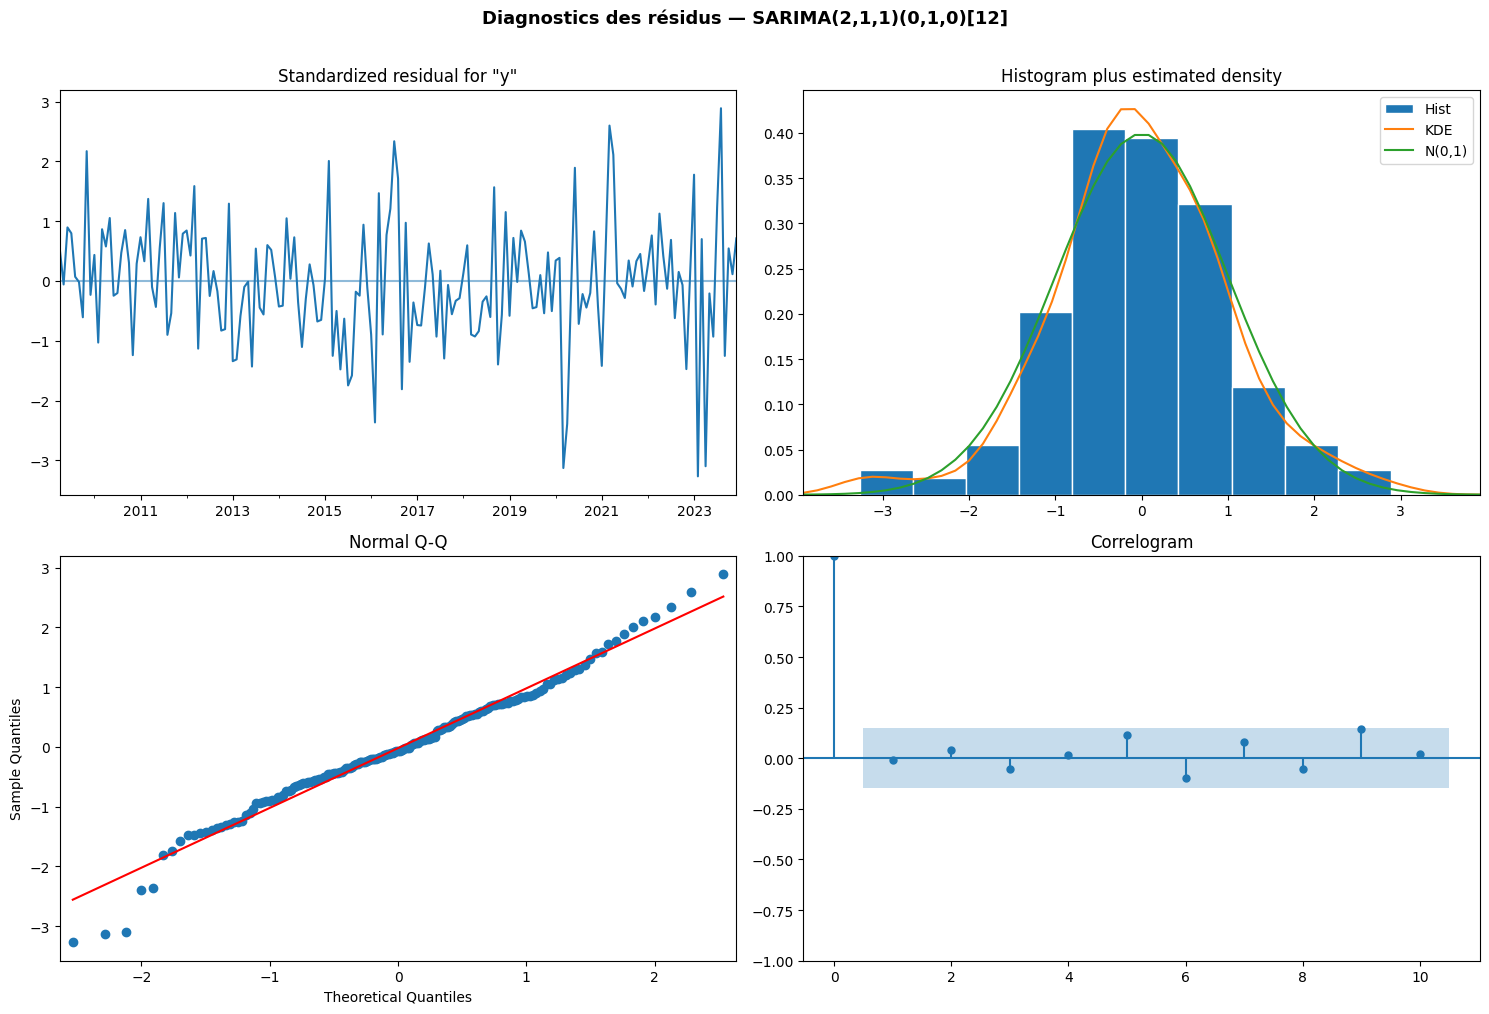

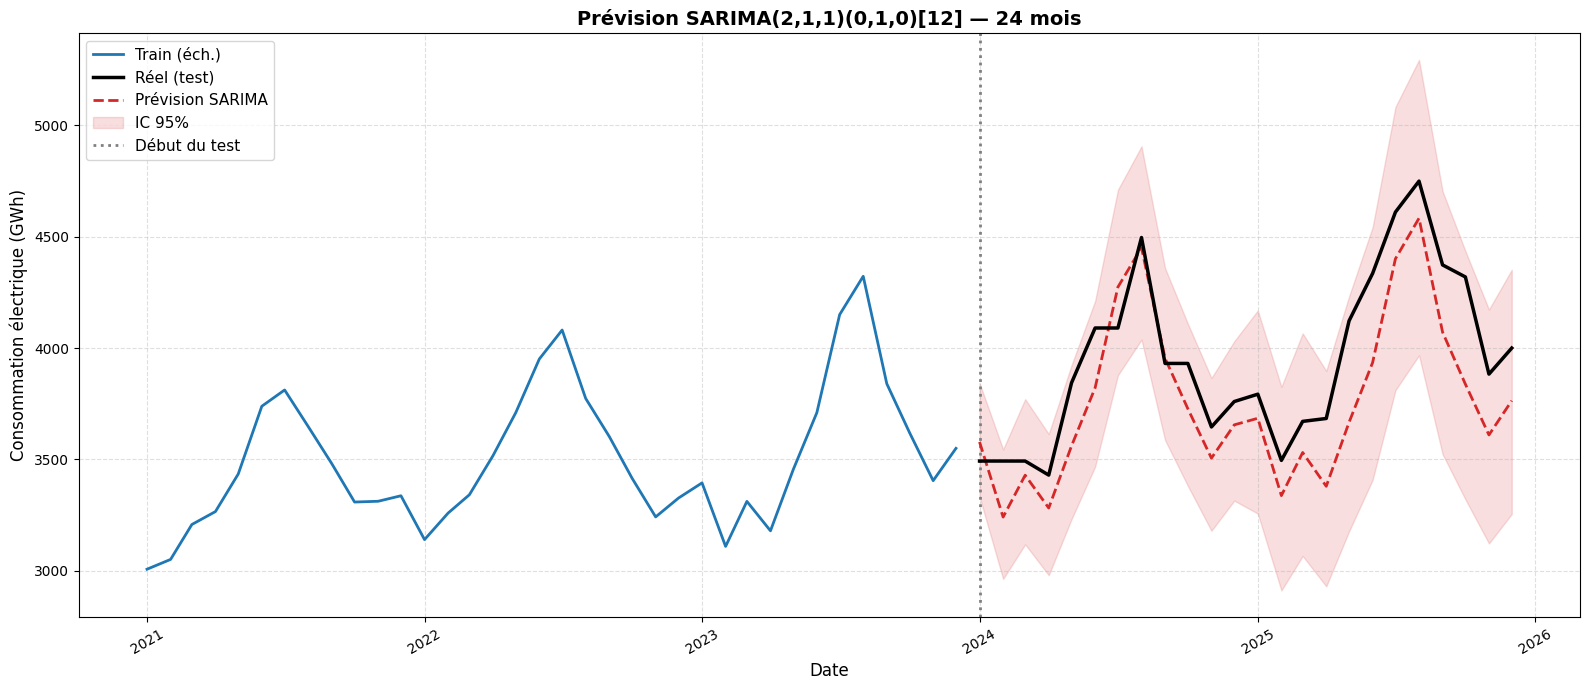

📊 ÉVALUATION — SARIMA(2,1,1)(0,1,0)[12]
  MAE   : 209.72 GWh
  RMSE  : 241.28 GWh
  MAPE  : 5.26 %
  sMAPE : 5.44 %


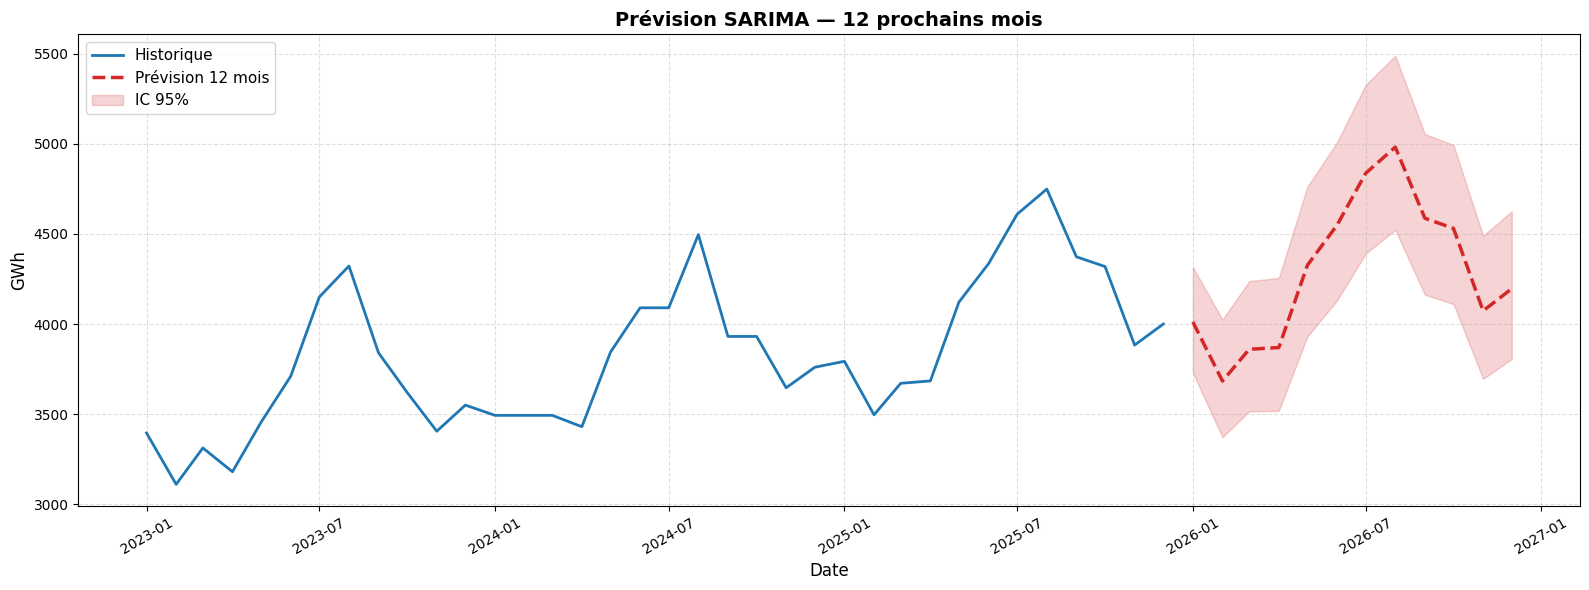


📅 Prévision détaillée des 12 prochains mois :
         Prévision (GWh)  IC inf 95%  IC sup 95%
2026-01           4011.0      3728.0      4316.0
2026-02           3683.0      3371.0      4025.0
2026-03           3860.0      3515.0      4238.0
2026-04           3869.0      3518.0      4256.0
2026-05           4327.0      3931.0      4763.0
2026-06           4549.0      4131.0      5009.0
2026-07           4837.0      4391.0      5328.0
2026-08           4982.0      4522.0      5489.0
2026-09           4587.0      4163.0      5055.0
2026-10           4531.0      4111.0      4993.0
2026-11           4073.0      3695.0      4490.0
2026-12           4196.0      3806.0      4626.0


In [14]:
# ============================================================
# SARIMA — Étape 3 : Diagnostics, Prévision et Évaluation
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Diagnostics des résidus ───────────────────────────────────
best_fit.plot_diagnostics(figsize=(15, 10))
plt.suptitle(f"Diagnostics des résidus — SARIMA({p},{d},{q})({P},{D},{Q})[{s}]",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Prévision sur la période de test ─────────────────────────
forecast_log   = best_fit.get_forecast(steps=n_test)
forecast_mean  = forecast_log.predicted_mean
forecast_ci    = forecast_log.conf_int(alpha=0.05)

# Retransformer en GWh (exp pour annuler le log)
forecast_gwh   = np.exp(forecast_mean)
ci_lower_gwh   = np.exp(forecast_ci.iloc[:, 0])
ci_upper_gwh   = np.exp(forecast_ci.iloc[:, 1])
actual_gwh     = series.iloc[-n_test:]          # valeurs réelles en GWh
train_gwh      = series.iloc[:-n_test]          # train en GWh

# ── Graphique de prévision ────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))

# Série d'entraînement (derniers 3 ans pour la lisibilité)
ax.plot(train_gwh.index[-36:], train_gwh.values[-36:],
        color='#1f77b4', linewidth=2, label='Train (éch.)')

# Valeurs réelles (test)
ax.plot(actual_gwh.index, actual_gwh.values,
        color='black', linewidth=2.5, label='Réel (test)', zorder=5)

# Prévisions
ax.plot(forecast_gwh.index, forecast_gwh.values,
        color='#d62728', linewidth=2, linestyle='--', label='Prévision SARIMA', zorder=4)

# Intervalle de confiance 95%
ax.fill_between(forecast_gwh.index, ci_lower_gwh, ci_upper_gwh,
                color='#d62728', alpha=0.15, label='IC 95%')

ax.axvline(actual_gwh.index[0], color='gray', linestyle=':', linewidth=2,
           label='Début du test')

ax.set_title(f"Prévision SARIMA({p},{d},{q})({P},{D},{Q})[{s}] — {n_test} mois",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Consommation électrique (GWh)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# ── Métriques d'évaluation ────────────────────────────────────
mae   = mean_absolute_error(actual_gwh, forecast_gwh)
rmse  = np.sqrt(mean_squared_error(actual_gwh, forecast_gwh))
mape  = np.mean(np.abs((actual_gwh.values - forecast_gwh.values) / actual_gwh.values)) * 100
smape = np.mean(2 * np.abs(actual_gwh.values - forecast_gwh.values) /
                (np.abs(actual_gwh.values) + np.abs(forecast_gwh.values))) * 100

print("=" * 50)
print(f"📊 ÉVALUATION — SARIMA({p},{d},{q})({P},{D},{Q})[{s}]")
print("=" * 50)
print(f"  MAE   : {mae:.2f} GWh")
print(f"  RMSE  : {rmse:.2f} GWh")
print(f"  MAPE  : {mape:.2f} %")
print(f"  sMAPE : {smape:.2f} %")

# ── Prévision future (12 mois suivants) ──────────────────────
final_model = SARIMAX(series_log,
                      order=(p, d, q),
                      seasonal_order=(P, D, Q, s),
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)

future_log  = final_model.get_forecast(steps=12)
future_mean = np.exp(future_log.predicted_mean)
future_ci   = future_log.conf_int(alpha=0.05)
future_lo   = np.exp(future_ci.iloc[:, 0])
future_hi   = np.exp(future_ci.iloc[:, 1])

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(series.index[-36:], series.values[-36:],
        color='#1f77b4', linewidth=2, label='Historique')
ax.plot(future_mean.index, future_mean.values,
        color='#d62728', linewidth=2.5, linestyle='--', label='Prévision 12 mois')
ax.fill_between(future_mean.index, future_lo, future_hi,
                color='#d62728', alpha=0.2, label='IC 95%')

ax.set_title("Prévision SARIMA — 12 prochains mois", fontsize=14, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("GWh", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print("\n📅 Prévision détaillée des 12 prochains mois :")
future_df = pd.DataFrame({
    'Prévision (GWh)' : future_mean.values.round(0),
    'IC inf 95%'      : future_lo.values.round(0),
    'IC sup 95%'      : future_hi.values.round(0)
}, index=future_mean.index.strftime('%Y-%m'))
print(future_df.to_string())


Dernière observation : December 2025
Prévision jusqu'à   : December 2030
Nombre de pas       : 60 mois
Modèle              : SARIMA(1,1,1)(1,1,1)[12]

⏳ Ajustement du modèle sur toute la série...
✅ Modèle ajusté !
   AIC : -727.18  |  BIC : -710.97


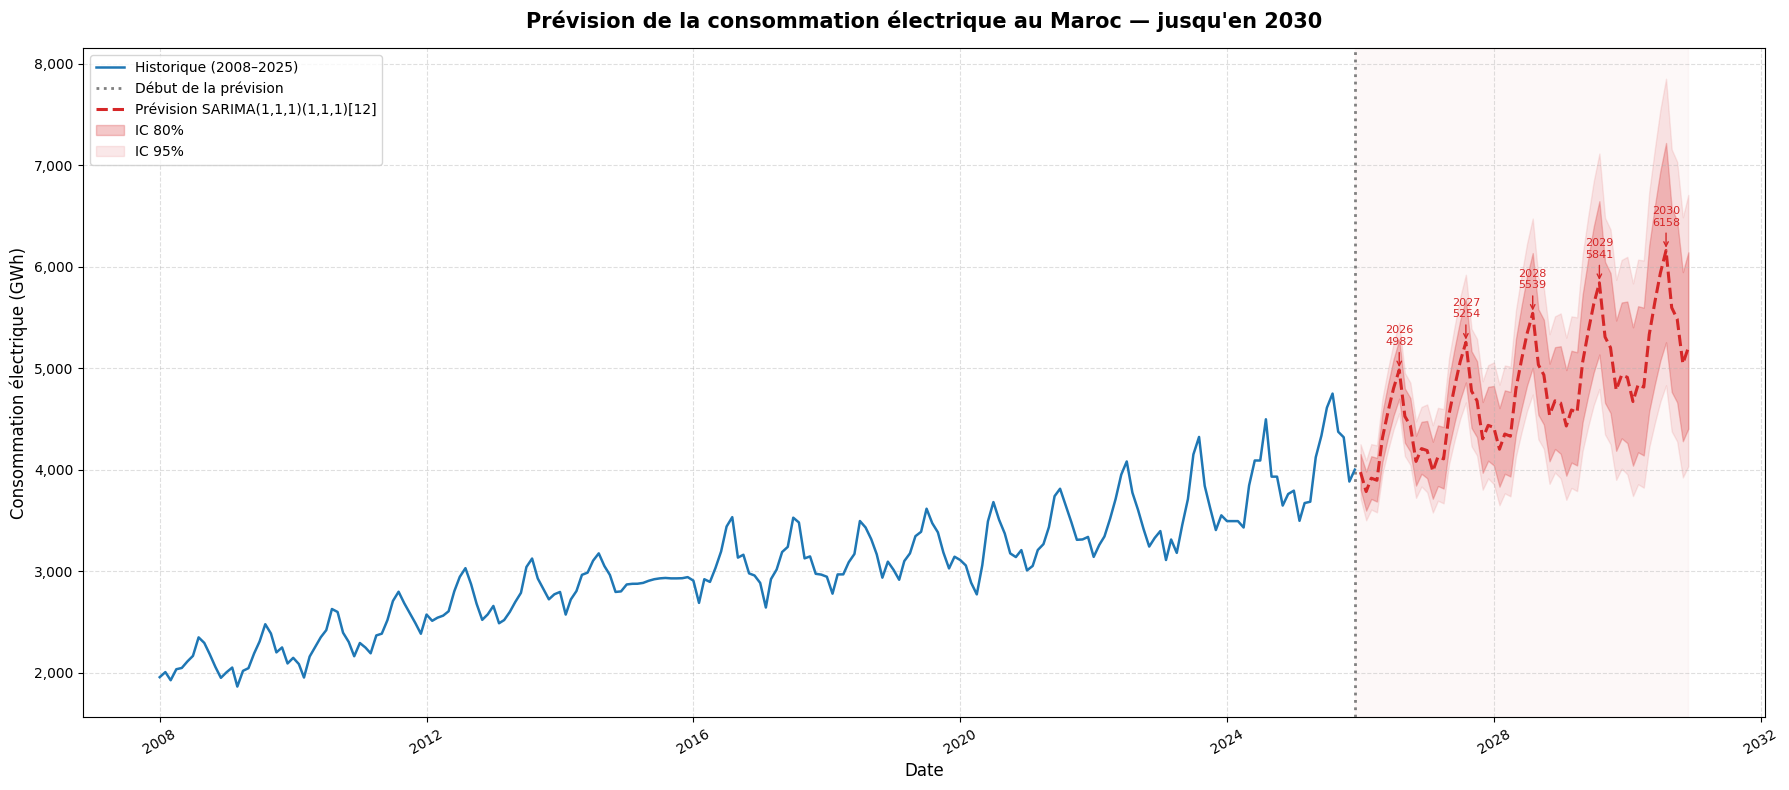

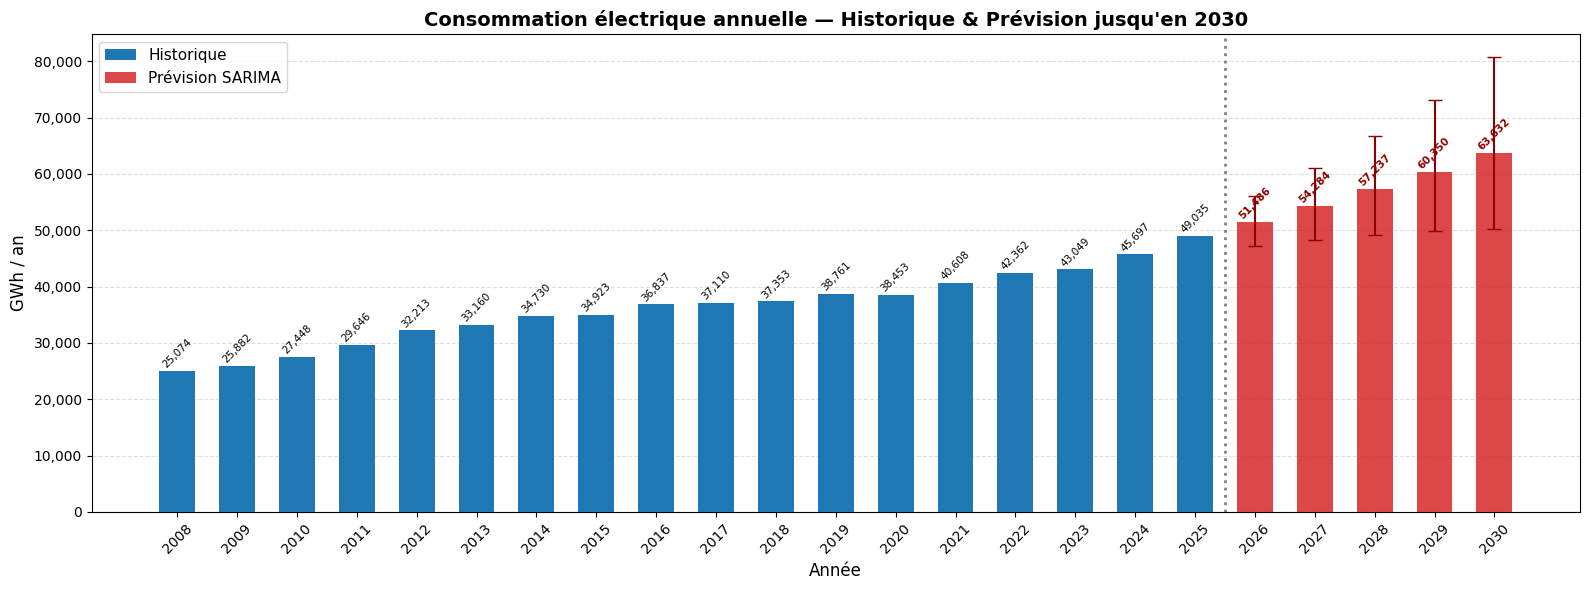

PRÉVISION SARIMA(1,1,1)(1,1,1)[12] — mensuelle jusqu'en 2030
            Prévision (GWh)  IC inf 80%  IC sup 80%  IC inf 95%  IC sup 95%
Année Mois                                                                 
2026  Jan           3,975.4     3,805.6     4,152.9     3,718.6     4,250.0
      Fév           3,784.4     3,596.6     3,982.0     3,501.0     4,090.7
      Mar           3,915.9     3,711.0     4,132.2     3,606.9     4,251.5
      Avr           3,895.2     3,685.7     4,116.5     3,579.4     4,238.8
      Mai           4,312.0     4,076.0     4,561.6     3,956.3     4,699.6
      Jun           4,573.7     4,319.9     4,842.3     4,191.4     4,990.9
      Jul           4,801.1     4,531.6     5,086.6     4,395.1     5,244.6
      Aoû           4,981.7     4,699.0     5,281.4     4,556.0     5,447.2
      Sep           4,524.6     4,265.3     4,799.8     4,134.1     4,952.1
      Oct           4,433.3     4,176.6     4,705.6     4,046.9     4,856.5
      Nov           4,081.0

In [16]:
# ============================================================
# SARIMA — Prévision jusqu'en 2030
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.statespace.sarimax import SARIMAX

series = final_data['Electricity_Consumption'].copy()
series_log = np.log(series)
series_log = pd.Series(series_log.values, index=series.index)

# ── Paramètres du meilleur modèle (issus de la sélection AIC) ─
# Remplacez par vos valeurs si différentes
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 12

# ── Calculer le nombre de mois jusqu'à décembre 2030 ─────────
last_date    = series.index[-1]
target_date  = pd.Timestamp('2030-12-01')
n_steps      = (target_date.year - last_date.year) * 12 + (target_date.month - last_date.month)

print(f"Dernière observation : {last_date.strftime('%B %Y')}")
print(f"Prévision jusqu'à   : {target_date.strftime('%B %Y')}")
print(f"Nombre de pas       : {n_steps} mois")
print(f"Modèle              : SARIMA({p},{d},{q})({P},{D},{Q})[{s}]")
print("\n⏳ Ajustement du modèle sur toute la série...")

# ── Entraîner le modèle sur TOUTE la série ────────────────────
model = SARIMAX(series_log,
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False)
fit = model.fit(disp=False)
print("✅ Modèle ajusté !")
print(f"   AIC : {fit.aic:.2f}  |  BIC : {fit.bic:.2f}")

# ── Prévision ─────────────────────────────────────────────────
forecast_obj  = fit.get_forecast(steps=n_steps)
forecast_log  = forecast_obj.predicted_mean
forecast_ci   = forecast_obj.conf_int(alpha=0.05)

# Retransformer en GWh
forecast_gwh  = np.exp(forecast_log)
ci_lower_gwh  = np.exp(forecast_ci.iloc[:, 0])
ci_upper_gwh  = np.exp(forecast_ci.iloc[:, 1])
ci_lower_80   = np.exp(forecast_obj.conf_int(alpha=0.20).iloc[:, 0])
ci_upper_80   = np.exp(forecast_obj.conf_int(alpha=0.20).iloc[:, 1])

# ── Graphique principal ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 8))

# Historique complet
ax.plot(series.index, series.values,
        color='#1f77b4', linewidth=1.8, label='Historique (2008–2025)', zorder=4)

# Ligne de séparation
ax.axvline(series.index[-1], color='gray', linestyle=':', linewidth=2,
           label='Début de la prévision', zorder=3)

# Prévision
ax.plot(forecast_gwh.index, forecast_gwh.values,
        color='#d62728', linewidth=2.2, linestyle='--',
        label=f'Prévision SARIMA({p},{d},{q})({P},{D},{Q})[{s}]', zorder=5)

# Intervalles de confiance
ax.fill_between(forecast_gwh.index, ci_lower_80, ci_upper_80,
                color='#d62728', alpha=0.25, label='IC 80%')
ax.fill_between(forecast_gwh.index, ci_lower_gwh, ci_upper_gwh,
                color='#d62728', alpha=0.10, label='IC 95%')

# Annotations annuelles (pic d'été de chaque année prévisionnelle)
for year in range(series.index[-1].year + 1, 2031):
    yr_data = forecast_gwh[forecast_gwh.index.year == year]
    if len(yr_data) == 0:
        continue
    peak_date = yr_data.idxmax()
    peak_val  = yr_data.max()
    ax.annotate(f'{year}\n{peak_val:.0f}',
                xy=(peak_date, peak_val),
                xytext=(0, 18), textcoords='offset points',
                fontsize=8, ha='center', color='#d62728',
                arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.0))

# Style
ax.set_title("Prévision de la consommation électrique au Maroc — jusqu'en 2030",
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Consommation électrique (GWh)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(axis='x', rotation=30)

# Zone de prévision en fond léger
ax.axvspan(series.index[-1], forecast_gwh.index[-1],
           color='#d62728', alpha=0.03, zorder=1)

plt.tight_layout()
plt.show()

# ── Graphique annuel agrégé (bar chart) ───────────────────────
annual_hist     = series.resample('YE').sum()
annual_forecast = forecast_gwh.resample('YE').sum()

fig, ax = plt.subplots(figsize=(16, 6))

bars_hist = ax.bar(annual_hist.index.year, annual_hist.values,
                   color='#1f77b4', width=0.6, label='Historique', zorder=3)
bars_fore = ax.bar(annual_forecast.index.year, annual_forecast.values,
                   color='#d62728', width=0.6, alpha=0.85,
                   label='Prévision SARIMA', zorder=3)

# IC annuel
annual_lo = ci_lower_gwh.resample('YE').sum()
annual_hi = ci_upper_gwh.resample('YE').sum()
ax.errorbar(annual_forecast.index.year, annual_forecast.values,
            yerr=[annual_forecast.values - annual_lo.values,
                  annual_hi.values - annual_forecast.values],
            fmt='none', color='#8B0000', linewidth=1.5, capsize=5, zorder=4)

# Étiquettes sur les barres
for bar in bars_hist:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=7.5, rotation=45)
for bar in bars_fore:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{bar.get_height():,.0f}', ha='center', va='bottom',
            fontsize=7.5, rotation=45, color='#8B0000', fontweight='bold')

ax.axvline(series.index[-1].year + 0.5, color='gray', linestyle=':', linewidth=2)
ax.set_title("Consommation électrique annuelle — Historique & Prévision jusqu'en 2030",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("GWh / an", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
ax.set_xticks(list(annual_hist.index.year) + list(annual_forecast.index.year))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# ── Tableau de prévision détaillé ─────────────────────────────
mois_fr = {1:'Jan',2:'Fév',3:'Mar',4:'Avr',5:'Mai',6:'Jun',
           7:'Jul',8:'Aoû',9:'Sep',10:'Oct',11:'Nov',12:'Déc'}

df_forecast = pd.DataFrame({
    'Année'           : forecast_gwh.index.year,
    'Mois'            : [mois_fr[m] for m in forecast_gwh.index.month],
    'Prévision (GWh)' : forecast_gwh.values.round(1),
    'IC inf 80%'      : ci_lower_80.values.round(1),
    'IC sup 80%'      : ci_upper_80.values.round(1),
    'IC inf 95%'      : ci_lower_gwh.values.round(1),
    'IC sup 95%'      : ci_upper_gwh.values.round(1),
}).set_index(['Année', 'Mois'])

print("=" * 70)
print(f"PRÉVISION SARIMA({p},{d},{q})({P},{D},{Q})[{s}] — mensuelle jusqu'en 2030")
print("=" * 70)
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', '{:,.1f}'.format)
print(df_forecast.to_string())

# ── Résumé annuel ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("RÉSUMÉ ANNUEL DES PRÉVISIONS")
print("=" * 55)
summary = pd.DataFrame({
    'Total (GWh)'   : annual_forecast.values.round(0),
    'IC inf 95%'    : annual_lo.values.round(0),
    'IC sup 95%'    : annual_hi.values.round(0),
}, index=annual_forecast.index.year)
summary.index.name = 'Année'

# Croissance vs année précédente
prev_total = pd.concat([annual_hist.iloc[[-1]], annual_forecast])
summary['Croissance vs N-1'] = (
    annual_forecast.values / prev_total.iloc[:-1].values - 1
) * 100

summary['Croissance vs N-1'] = summary['Croissance vs N-1'].map('{:+.2f}%'.format)
summary['Total (GWh)']       = summary['Total (GWh)'].astype(int)
summary['IC inf 95%']        = summary['IC inf 95%'].astype(int)
summary['IC sup 95%']        = summary['IC sup 95%'].astype(int)
print(summary.to_string())


In [1]:
import pandas as pd

qatar_demand_df = pd.read_csv(r"C:\Users\Hp\Downloads\qatar_monthly_electricity_demand.csv")
qatar_demand_df.head()


,Area,ISO 3 code,Date,Area type,Continent,Ember region,EU,OECD,G20,G7,ASEAN,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
0,Qatar,QAT,2018-01-01,Country or economy,Asia,Middle East,0.0,0.0,0.0,0.0,0.0,Electricity demand,Demand,Demand,TWh,2.47,NaN,NaN
1,Qatar,QAT,2018-02-01,Country or economy,Asia,Middle East,0.0,0.0,0.0,0.0,0.0,Electricity demand,Demand,Demand,TWh,2.29,NaN,NaN
2,Qatar,QAT,2018-03-01,Country or economy,Asia,Middle East,0.0,0.0,0.0,0.0,0.0,Electricity demand,Demand,Demand,TWh,2.51,NaN,NaN
3,Qatar,QAT,2018-04-01,Country or economy,Asia,Middle East,0.0,0.0,0.0,0.0,0.0,Electricity demand,Demand,Demand,TWh,2.78,NaN,NaN
4,Qatar,QAT,2018-05-01,Country or economy,Asia,Middle East,0.0,0.0,0.0,0.0,0.0,Electricity demand,Demand,Demand,TWh,3.50,NaN,NaN


Plot saved successfully to C:\Users\Hp\.gemini\antigravity\brain\f4bbbd15-ec8d-4b3a-9502-8e9f2b713432\scratch\qatar_demand_plot.png


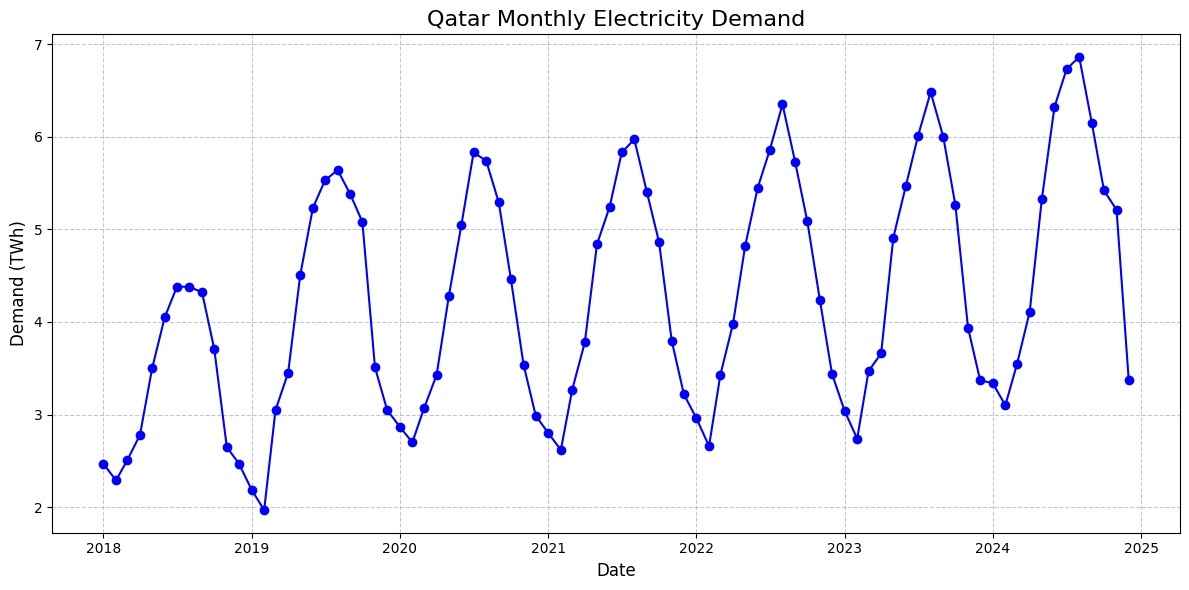

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    # Load the data
    df = pd.read_csv(r"C:\Users\Hp\Downloads\qatar_monthly_electricity_demand.csv")
    
    # Ensure Date is a datetime object
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Sort by date
    df = df.sort_values(by='Date')
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(df['Date'], df['Value'], marker='o', linestyle='-', color='b')
    plt.title('Qatar Monthly Electricity Demand', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Demand (TWh)', fontsize=12) # Assuming unit is TWh based on common units for this dataset, or we can check the 'Unit' column.
    if 'Unit' in df.columns:
        unit = df['Unit'].iloc[0]
        plt.ylabel(f'Demand ({unit})', fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save the plot
    output_img = r"C:\Users\Hp\.gemini\antigravity\brain\f4bbbd15-ec8d-4b3a-9502-8e9f2b713432\scratch\qatar_demand_plot.png"
    plt.savefig(output_img)
    print(f"Plot saved successfully to {output_img}")
except Exception as e:
    print(f"Error generating plot: {e}")



Yearly Electricity Demand for Qatar:
   Year  Value
0  2018  39.51
1  2019  48.59
2  2020  49.25
3  2021  51.63
4  2022  54.01
5  2023  54.35
6  2024  59.49


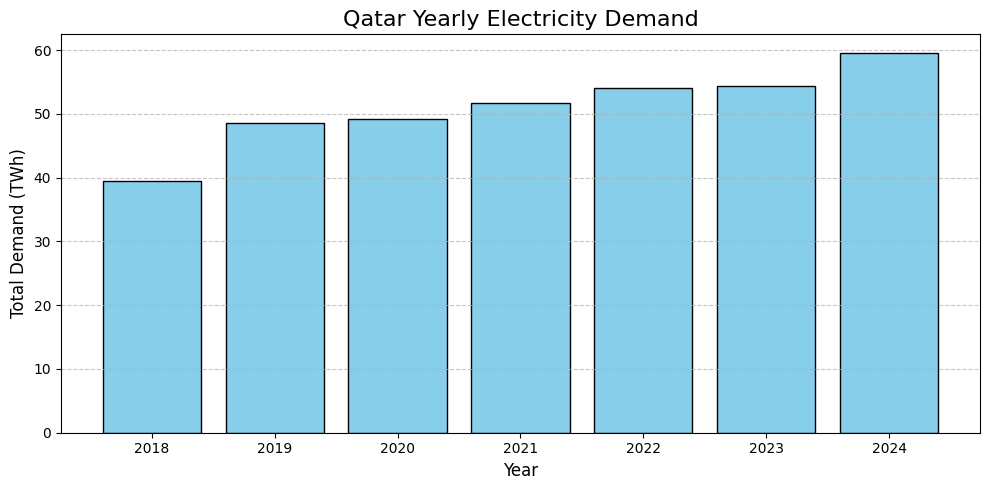

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the monthly data
df = pd.read_csv(r"C:\Users\Hp\Downloads\qatar_monthly_electricity_demand.csv")

# 2. Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# 3. Extract the Year into a new column
df['Year'] = df['Date'].dt.year

# 4. Group by Year and sum the 'Value' column
yearly_demand = df.groupby('Year')['Value'].sum().reset_index()

# 5. Display the calculated yearly data
print("Yearly Electricity Demand for Qatar:")
print(yearly_demand)

# 6. Plot the Yearly Demand
plt.figure(figsize=(10, 5))
plt.bar(yearly_demand['Year'].astype(str), yearly_demand['Value'], color='skyblue', edgecolor='black')

plt.title('Qatar Yearly Electricity Demand', fontsize=16)
plt.xlabel('Year', fontsize=12)

# Get the unit if available
unit = df['Unit'].iloc[0] if 'Unit' in df.columns else 'TWh'
plt.ylabel(f'Total Demand ({unit})', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Hp\AppData\Local\Temp\ipykernel_17484\1047013001.py:13: SyntaxWarning: invalid escape sequence '\d'
  df_melted['year'] = df_melted['Year'].str.extract('(\d+)').astype(int)


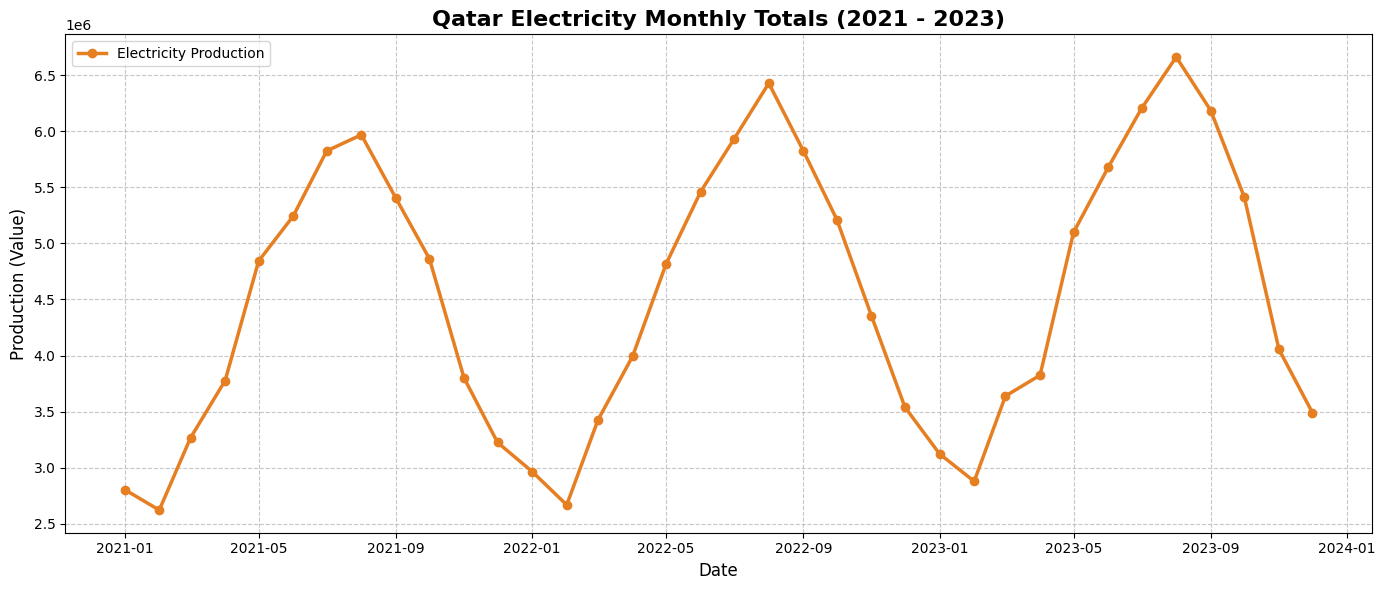

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
file_path = r"C:\Users\Hp\Downloads\qatar_electricity_monthly_totals_2021_2023.csv"
df = pd.read_csv(file_path)

# 2. Reshape the data
df_melted = df.melt(id_vars=['Month'], var_name='Year', value_name='Production')

# 3. Clean and Create Date column (FIXED NAMES)
# We rename columns to 'year', 'month', and 'day' for pd.to_datetime
df_melted['year'] = df_melted['Year'].str.extract('(\d+)').astype(int)

month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_melted['month'] = df_melted['Month'].map(month_map)
df_melted['day'] = 1  # Add a day column

# Assemble the date using the lowercase column names
df_melted['Date'] = pd.to_datetime(df_melted[['year', 'month', 'day']])

# Sort by date
df_melted = df_melted.sort_values('Date')

# 4. Plotting
plt.figure(figsize=(14, 6))
plt.plot(df_melted['Date'], df_melted['Production'], marker='o', linewidth=2.5, color='#e67e22', label='Electricity Production')

plt.title('Qatar Electricity Monthly Totals (2021 - 2023)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Production (Value)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()


In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\Users\Hp\Downloads\monthly_full_release_long_format (1).csv")

# Filter: Russia + Electricity demand
russia_demand = df[
    (df["Area"] == "Russian Federation (the)") &
    (df["Variable"] == "Demand") &
    (df["Category"] == "Electricity demand")
][["Date", "Value"]].copy()

# Format the Date column and sort
russia_demand["Date"] = pd.to_datetime(russia_demand["Date"])
russia_demand = russia_demand.sort_values("Date").reset_index(drop=True)
russia_demand.rename(columns={"Value": "Demand (TWh)"}, inplace=True)

print(russia_demand)
print(f"\nShape: {russia_demand.shape}")


         Date  Demand (TWh)
0  2019-01-01        102.82
1  2019-02-01         92.36
2  2019-03-01         95.66
3  2019-04-01         85.93
4  2019-05-01         81.11
..        ...           ...
81 2025-10-01         98.30
82 2025-11-01        100.73
83 2025-12-01        111.58
84 2026-01-01        114.65
85 2026-02-01        103.53

[86 rows x 2 columns]

Shape: (86, 2)


In [1]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(russia_demand["Date"], russia_demand["Demand (TWh)"], color="steelblue", linewidth=1.5)
plt.title("Russia — Monthly Electricity Demand", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Demand (TWh)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'russia_demand' is not defined

<Figure size 1400x500 with 0 Axes>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
base_path = r"C:\Users\Hp\OneDrive\Desktop\Data\Data Time series project"


C:\Users\Hp\AppData\Local\Temp\ipykernel_9776\1710121442.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_qatar['Date'] = pd.to_datetime(df_qatar['Year'].astype(str) + ' ' + df_qatar['Month'])


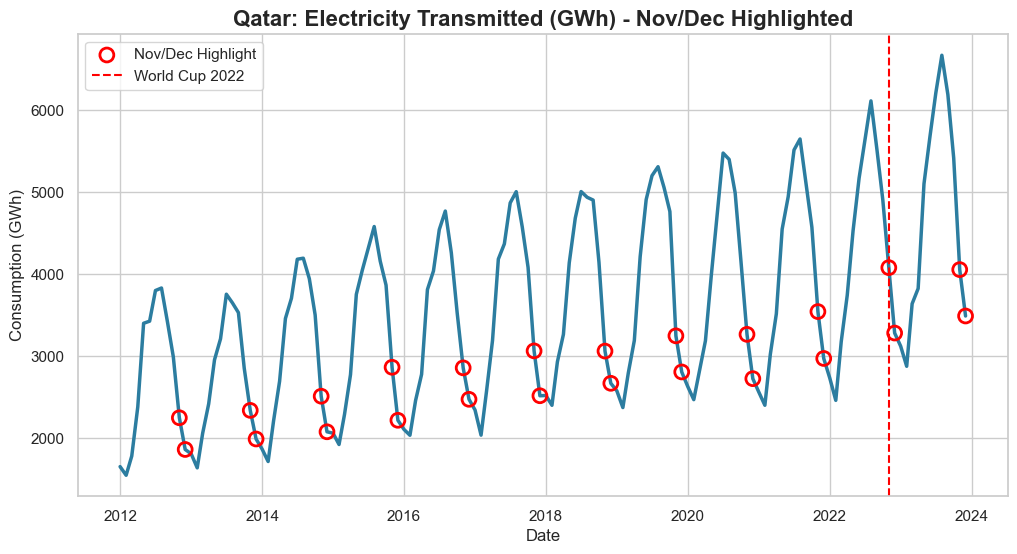

In [3]:
# Load Qatar Data
qatar_path = f"{base_path}\\qatar_electricity_transmitted (1).csv"
df_qatar = pd.read_csv(qatar_path)
df_qatar['Date'] = pd.to_datetime(df_qatar['Year'].astype(str) + ' ' + df_qatar['Month'])
df_qatar = df_qatar.sort_values('Date')

# Convert MWh to GWh
df_qatar['Total_GWh'] = df_qatar['Total_MWh'] / 1000

# Create a filter for November and December
highlight_df = df_qatar[df_qatar['Date'].dt.month.isin([11, 12])]

# Plot
plt.figure(figsize=(12, 6))
# Main line plot
sns.lineplot(data=df_qatar, x='Date', y='Total_GWh', color='#2c7da0', linewidth=2.5)

# Highlight Nov/Dec with red circles
plt.scatter(highlight_df['Date'], highlight_df['Total_GWh'], 
            facecolors='none', edgecolors='red', s=100, linewidth=2, 
            label='Nov/Dec Highlight', zorder=5)

# World Cup Indicator
plt.axvline(pd.to_datetime('2022-11-01'), color='red', linestyle='--', label='World Cup 2022')

plt.title('Qatar: Electricity Transmitted (GWh) - Nov/Dec Highlighted', fontsize=16, fontweight='bold')
plt.ylabel('Consumption (GWh)')
plt.legend()
plt.show()



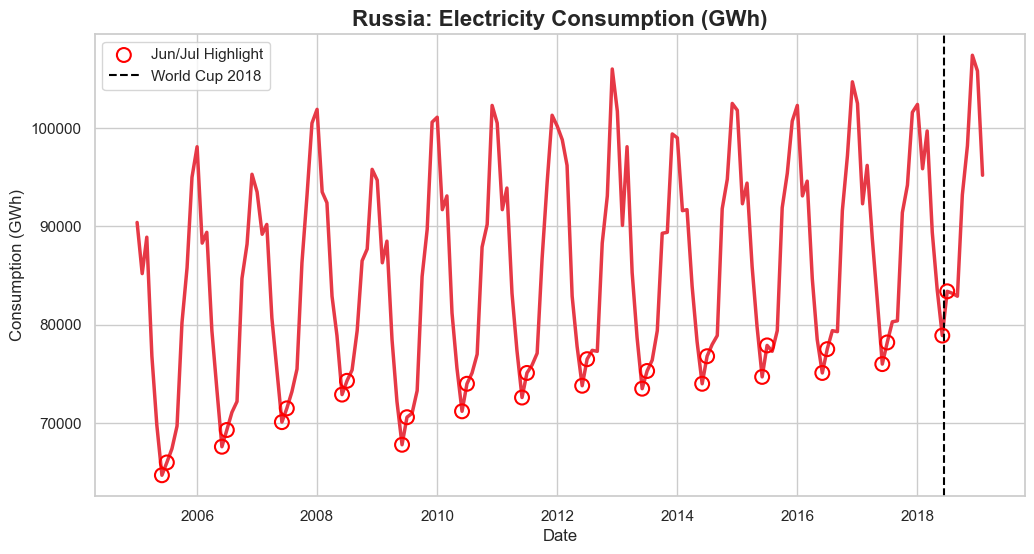

In [4]:
# Updated Cell 3: Russia Electricity Data (New Format)
russia_path = f"{base_path}\\Russia_data.csv"

# Load with new semicolon separator and header
df_russia = pd.read_csv(russia_path, sep=';')

# Convert the 'Month' column (e.g., "Jan '13") to datetime
df_russia['Date'] = pd.to_datetime(df_russia['Month'], format="%b '%y")

# Convert Billion kWh (TWh) to GWh (1 Billion kWh = 1000 GWh)
df_russia['Consumption_GWh'] = pd.to_numeric(df_russia['Consumption (kWh bn)']) * 1000

# Sort by date for proper time series plotting
df_russia = df_russia.sort_values('Date')

# --- NEW: Filter for June and July 2018 ---
# --- Highlight every June and July ---
highlight_months = df_russia[df_russia['Date'].dt.month.isin([6, 7])]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_russia, x='Date', y='Consumption_GWh', color='#e63946', linewidth=2.5)

# Add red circles for every June and July
plt.scatter(highlight_months['Date'], highlight_months['Consumption_GWh'], 
            edgecolor='red', facecolor='none', s=100, linewidth=1.5, zorder=5, label='Jun/Jul Highlight')

plt.axvline(pd.to_datetime('2018-06-14'), color='black', linestyle='--', label='World Cup 2018')
plt.title('Russia: Electricity Consumption (GWh)', fontsize=16, fontweight='bold')
plt.ylabel('Consumption (GWh)')
plt.legend()
plt.show()


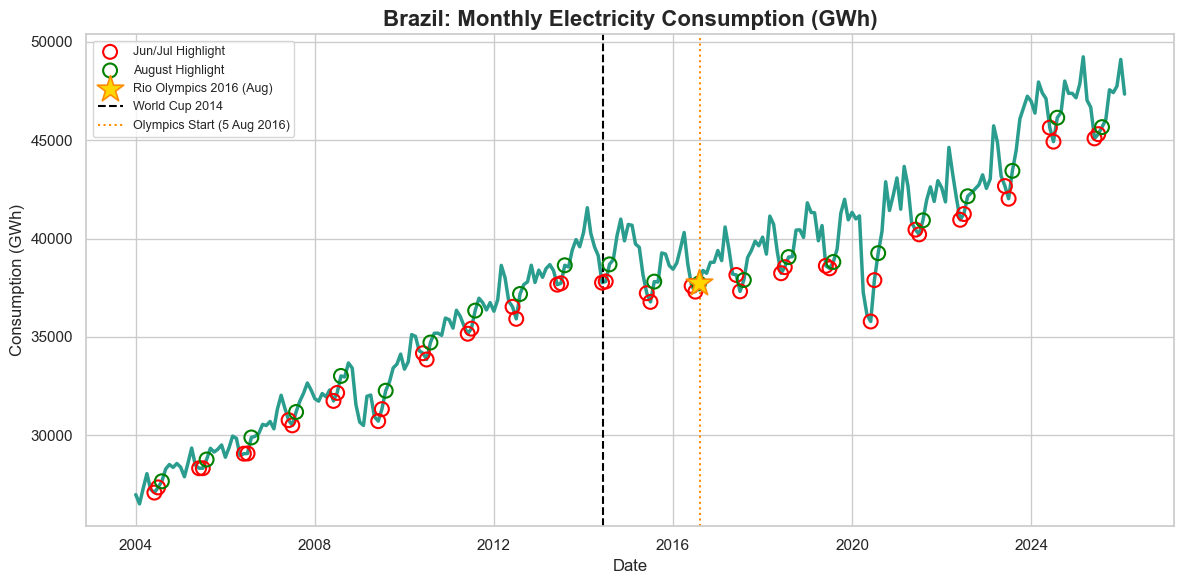

In [5]:
# Load Brazil Data
brazil_path = f"{base_path}\\brazil_monthly_electricity_consumption_2004-2026.csv"
df_brazil = pd.read_csv(brazil_path)
df_brazil['Date'] = pd.to_datetime(df_brazil['Month'])
df_brazil = df_brazil.sort_values('Date')

# Convert MWh to GWh
df_brazil['Consumption_GWh'] = df_brazil['Consumption_MWh'] / 1000

# --- Highlight groups ---
june_july_months  = df_brazil[df_brazil['Date'].dt.month.isin([6, 7])]   # Red circles
august_months     = df_brazil[df_brazil['Date'].dt.month == 8]            # Green circles
olympics_month    = df_brazil[df_brazil['Date'] == '2016-08-01']          # Gold star (Rio 2016)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_brazil, x='Date', y='Consumption_GWh', color='#2a9d8f', linewidth=2.5)

# Red hollow circles → Jun & Jul (every year)
plt.scatter(june_july_months['Date'], june_july_months['Consumption_GWh'],
            edgecolor='red', facecolor='none', s=100, linewidth=1.5,
            zorder=5, label='Jun/Jul Highlight')

# Green hollow circles → August (every year)
plt.scatter(august_months['Date'], august_months['Consumption_GWh'],
            edgecolor='green', facecolor='none', s=100, linewidth=1.5,
            zorder=5, label='August Highlight')

# Gold filled star → Rio 2016 Olympics (Aug 2016)
plt.scatter(olympics_month['Date'], olympics_month['Consumption_GWh'],
            marker='*', color='gold', edgecolor='darkorange', s=400,
            linewidth=1.2, zorder=6, label='Rio Olympics 2016 (Aug)')

# Reference lines
plt.axvline(pd.to_datetime('2014-06-12'), color='black', linestyle='--', linewidth=1.5, label='World Cup 2014')
plt.axvline(pd.to_datetime('2016-08-05'), color='darkorange', linestyle=':', linewidth=1.5, label='Olympics Start (5 Aug 2016)')

plt.title('Brazil: Monthly Electricity Consumption (GWh)', fontsize=16, fontweight='bold')
plt.ylabel('Consumption (GWh)')
plt.xlabel('Date')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()




In [6]:
# Load South Africa Data
sa_path = f"{base_path}\\South_Africa_Electricity_Available_for_Distribution_1991_2015.csv"
df_sa = pd.read_csv(sa_path)
df_sa['Date'] = pd.to_datetime(df_sa['Year'].astype(str) + ' ' + df_sa['Month'])
df_sa = df_sa.sort_values('Date')

# --- Highlight groups ---
june_july_months = df_sa[df_sa['Date'].dt.month.isin([6, 7])]     # Red circles
jan_feb_months   = df_sa[df_sa['Date'].dt.month.isin([1, 2])]     # Green circles

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_sa, x='Date', y='Consumption_GWh', color='#f4a261', linewidth=2.5)

# Red hollow circles → Jun & Jul
plt.scatter(june_july_months['Date'], june_july_months['Consumption_GWh'],
            edgecolor='red', facecolor='none', s=100, linewidth=1.5,
            zorder=5, label='Jun/Jul Highlight')

# Green hollow circles → Jan & Feb
plt.scatter(jan_feb_months['Date'], jan_feb_months['Consumption_GWh'],
            edgecolor='green', facecolor='none', s=100, linewidth=1.5,
            zorder=5, label='Jan/Feb Highlight')

plt.axvline(pd.to_datetime('2010-06-01'), color='green', linestyle='--', linewidth=1.5, label='World Cup 2010')
plt.title('South Africa: Electricity Available (GWh)', fontsize=16, fontweight='bold')
plt.ylabel('Consumption (GWh)')
plt.xlabel('Date')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()




FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Hp\\OneDrive\\Desktop\\Data\\Data Time series project\\South_Africa_Electricity_Available_for_Distribution_1991_2015.csv'

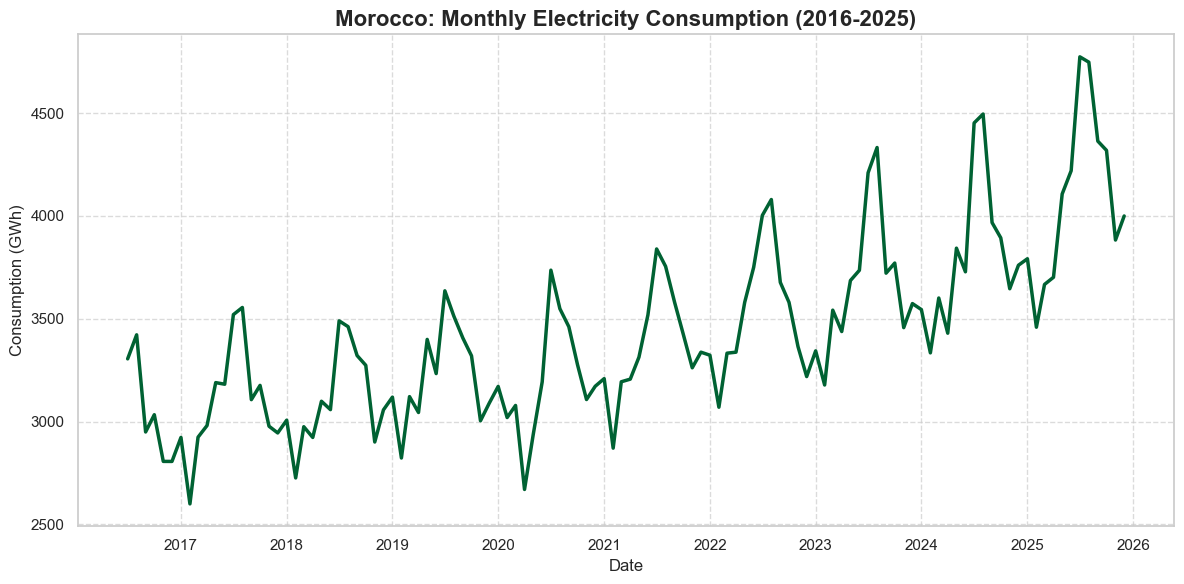

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File path
file_path = r"C:\Users\Hp\OneDrive\Desktop\Data\Data Time series project\consommation_electrique_maroc_2016_2025_final.csv"

# Load the data
df_morocco = pd.read_csv(file_path)

# Convert Date column to datetime and sort
df_morocco['Date'] = pd.to_datetime(df_morocco['Date'])
df_morocco = df_morocco.sort_values('Date')

# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_morocco, x='Date', y='Energie_GWh', color='#006233', linewidth=2.5)

plt.title('Morocco: Monthly Electricity Consumption (2016-2025)', fontsize=16, fontweight='bold')
plt.ylabel('Consumption (GWh)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


IEA range:  2019-01-01 → 2025-11-01  (83 rows)
Local range:2005-01-01 → 2019-02-01  (170 rows)

Combined:   2005-01-01 → 2025-11-01  (251 rows)


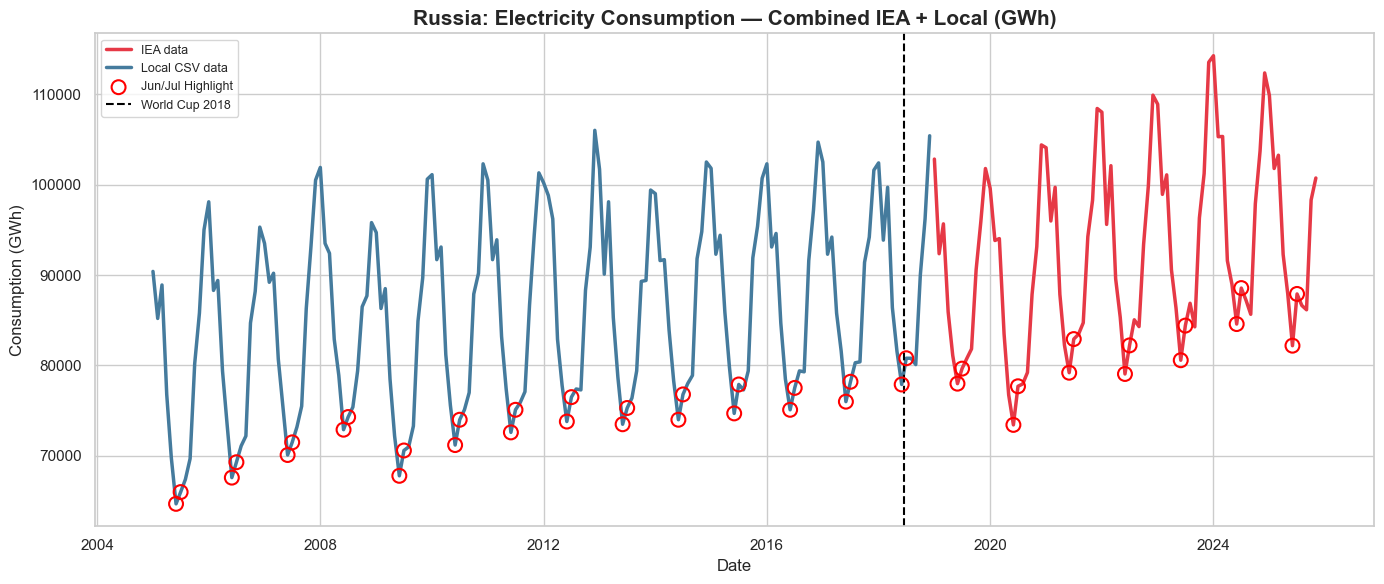

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── SOURCE 1: IEA Long-Format ──────────────────────────────────────────────────
df_iea = pd.read_csv(r"C:\Users\Hp\OneDrive\Desktop\Data\Data Time series project\monthly_full_release_long_format.csv")

russia_iea = df_iea[
    (df_iea["Area"] == "Russian Federation (the)") &
    (df_iea["Variable"] == "Demand") &
    (df_iea["Category"] == "Electricity demand")
][["Date", "Value"]].copy()

russia_iea["Date"] = pd.to_datetime(russia_iea["Date"])
russia_iea["Consumption_GWh"] = russia_iea["Value"] * 1000  # TWh → GWh
russia_iea["Source"] = "IEA"
russia_iea = russia_iea[["Date", "Consumption_GWh", "Source"]].sort_values("Date")
print(f"IEA range:  {russia_iea['Date'].min().date()} → {russia_iea['Date'].max().date()}  ({len(russia_iea)} rows)")

# ── SOURCE 2: Russia_data.csv ──────────────────────────────────────────────────
russia_path = f"{base_path}\\Russia_data.csv"
df_local = pd.read_csv(russia_path, sep=';')
df_local["Date"] = pd.to_datetime(df_local["Month"], format="%b '%y")
df_local["Consumption_GWh"] = pd.to_numeric(df_local["Consumption (kWh bn)"], errors="coerce") * 1000
df_local["Source"] = "Local"
df_local = df_local[["Date", "Consumption_GWh", "Source"]].sort_values("Date")
print(f"Local range:{df_local['Date'].min().date()} → {df_local['Date'].max().date()}  ({len(df_local)} rows)")

# ── COMBINE: IEA takes priority on overlapping months ─────────────────────────
combined = pd.concat([russia_iea, df_local], ignore_index=True)
combined = combined.sort_values(["Date", "Source"])

# Where both sources overlap, keep IEA (drop Local duplicates)
combined = combined.drop_duplicates(subset="Date", keep="first").reset_index(drop=True)
combined = combined.sort_values("Date")
print(f"\nCombined:   {combined['Date'].min().date()} → {combined['Date'].max().date()}  ({len(combined)} rows)")

# ── PLOT ───────────────────────────────────────────────────────────────────────
june_july = combined[combined["Date"].dt.month.isin([6, 7])]

# Color each segment by source so the join is visible
iea_seg   = combined[combined["Source"] == "IEA"]
local_seg = combined[combined["Source"] == "Local"]

plt.figure(figsize=(14, 6))
sns.lineplot(data=iea_seg,   x="Date", y="Consumption_GWh", color="#e63946", linewidth=2.5, label="IEA data")
sns.lineplot(data=local_seg, x="Date", y="Consumption_GWh", color="#457b9d", linewidth=2.5, label="Local CSV data")

# Red circles for Jun & Jul
plt.scatter(june_july["Date"], june_july["Consumption_GWh"],
            edgecolor="red", facecolor="none", s=100, linewidth=1.5, zorder=5, label="Jun/Jul Highlight")

plt.axvline(pd.to_datetime("2018-06-14"), color="black", linestyle="--", linewidth=1.5, label="World Cup 2018")
plt.title("Russia: Electricity Consumption — Combined IEA + Local (GWh)", fontsize=15, fontweight="bold")
plt.ylabel("Consumption (GWh)")
plt.xlabel("Date")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import os

# Paths
input_path = r"C:\Users\Hp\OneDrive\Desktop\Data\Data Time series project\monthly_full_release_long_format.csv"
output_path = r"C:\Users\Hp\OneDrive\Desktop\Data\Data Time series project\egypt_electricity_demand.csv"

# Load the long-format dataset
df = pd.read_csv(input_path)

# Filter for Egypt electricity demand
egypt_demand = df[
    (df["Area"] == "Egypt") &
    (df["Variable"] == "Demand") &
    (df["Category"] == "Electricity demand")
].copy()

# Sort by Date chronologically
egypt_demand["Date"] = pd.to_datetime(egypt_demand["Date"])
egypt_demand = egypt_demand.sort_values("Date").reset_index(drop=True)

# Select relevant columns and rename to TWh
egypt_demand = egypt_demand[["Date", "Value", "Unit"]].rename(columns={"Value": "Demand_TWh"})

# Add GWh column (1 TWh = 1000 GWh) for consistency with other project datasets
egypt_demand["Demand_GWh"] = egypt_demand["Demand_TWh"] * 1000

# Save to a new CSV file
egypt_demand.to_csv(output_path, index=False)

print(f"Extracted {len(egypt_demand)} months of data ({egypt_demand['Date'].min().strftime('%Y-%m')} to {egypt_demand['Date'].max().strftime('%Y-%m')})")
print(f"Saved to: {output_path}")


Extracted 111 months of data (2016-01 to 2025-03)
Saved to: C:\Users\Hp\OneDrive\Desktop\Data\Data Time series project\egypt_electricity_demand.csv


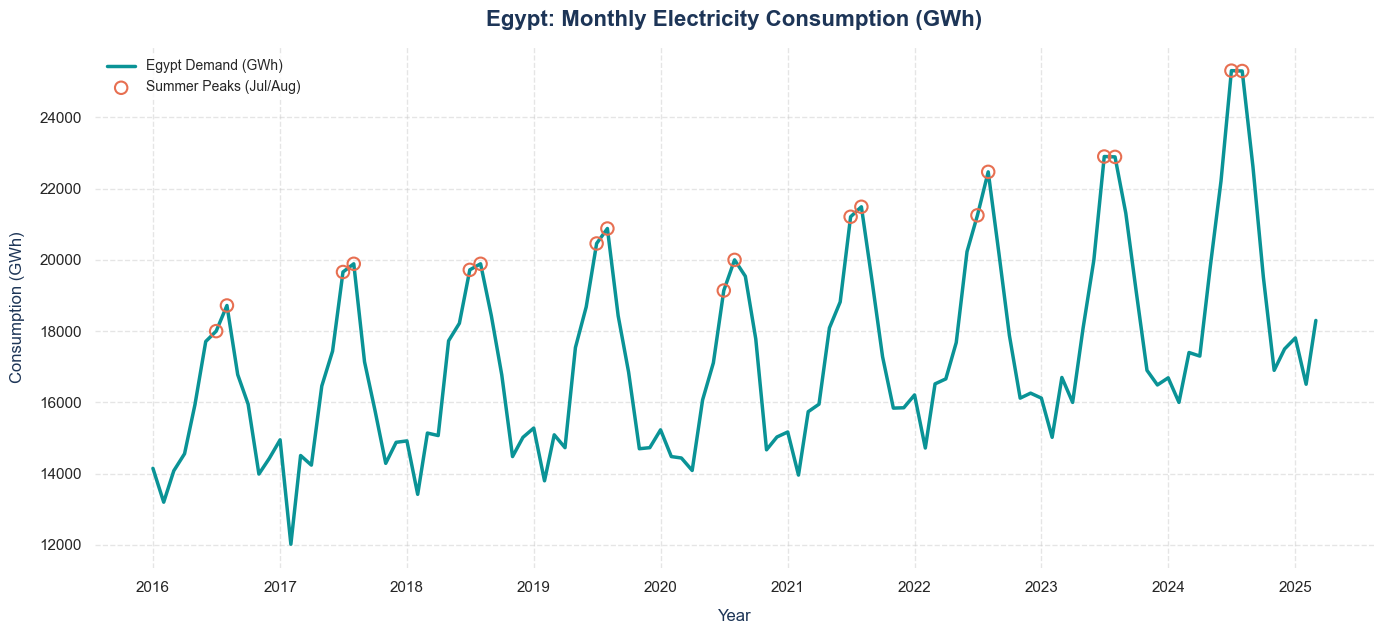

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Egypt data
egypt_path = r"C:\Users\Hp\OneDrive\Desktop\Data\Data Time series project\egypt_electricity_demand.csv"
df = pd.read_csv(egypt_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Select July & August to highlight (Egypt's peak air conditioning season)
highlight_months = df[df["Date"].dt.month.isin([7, 8])]

# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6.5))

# Plot demand line
plt.plot(df["Date"], df["Demand_GWh"], color="#0a9396", linewidth=2.5, label="Egypt Demand (GWh)", zorder=3)

# Highlight peak months (July & August) in orange hollow circles
plt.scatter(
    highlight_months["Date"], 
    highlight_months["Demand_GWh"], 
    edgecolor="#e76f51", 
    facecolor="none", 
    s=80, 
    linewidth=1.5, 
    zorder=4, 
    label="Summer Peaks (Jul/Aug)"
)

# Premium styling
plt.title("Egypt: Monthly Electricity Consumption (GWh)", fontsize=16, fontweight="bold", pad=15, color="#1d3557")
plt.ylabel("Consumption (GWh)", fontsize=12, labelpad=10, color="#1d3557")
plt.xlabel("Year", fontsize=12, labelpad=10, color="#1d3557")

plt.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=10, loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5, zorder=1)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


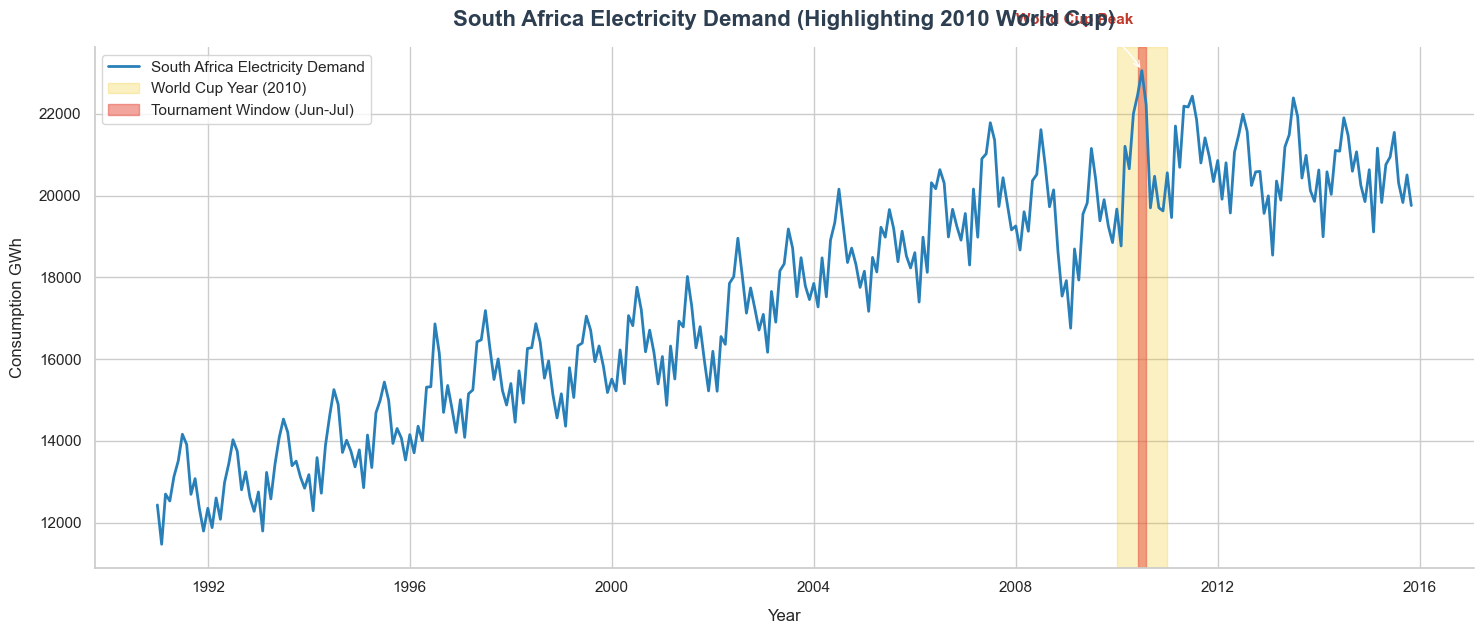

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File path provided
file_path = r"C:\Users\Hp\OneDrive\Desktop\Data\Data Time series project\south_africa_donor_electricity_demand.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Handle the datetime index dynamically
if 'Year' in df.columns and 'Month' in df.columns:
    df['date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'])
    df = df.set_index('date').sort_index()
elif 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

# Automatically select the first numeric column for the Y-axis if 'Consumption_GWh' isn't explicitly there
val_col = 'Consumption_GWh' if 'Consumption_GWh' in df.columns else df.select_dtypes(include='number').columns[0]

# ─── Plotting ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15, 6.5))

# Plot the main time series
ax.plot(df.index, df[val_col], color="#2980b9", lw=2, label="South Africa Electricity Demand")

# Highlight the entire World Cup Year (2010) with a light shade
ax.axvspan(pd.Timestamp("2010-01-01"), pd.Timestamp("2010-12-31"), 
           color="#f1c40f", alpha=0.25, label="World Cup Year (2010)")

# Highlight the exact tournament months (June-July 2010) with a darker, distinct color
ax.axvspan(pd.Timestamp("2010-06-01"), pd.Timestamp("2010-07-31"), 
           color="#e74c3c", alpha=0.5, label="Tournament Window (Jun-Jul)")

# Add a specific text annotation pointing to the peak
wc_peak_date = pd.Timestamp("2010-07-01")
if wc_peak_date in df.index:
    peak_val = df.loc[wc_peak_date, val_col]
    ax.annotate("World Cup Peak", 
                xy=(wc_peak_date, peak_val),
                xytext=(pd.Timestamp("2008-01-01"), peak_val + (df[val_col].max() * 0.05)),
                arrowprops=dict(facecolor="#c0392b", arrowstyle="->", connectionstyle="arc3,rad=-0.2"),
                fontsize=11, fontweight="bold", color="#c0392b")

# Formatting
ax.set_title("South Africa Electricity Demand (Highlighting 2010 World Cup)", 
             fontsize=16, fontweight="bold", pad=15, color="#2c3e50")
ax.set_ylabel(val_col.replace("_", " "), fontsize=12, labelpad=10)
ax.set_xlabel("Year", fontsize=12, labelpad=10)
ax.legend(frameon=True, facecolor="white", loc="upper left", fontsize=11)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_18732\2816181775.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'])


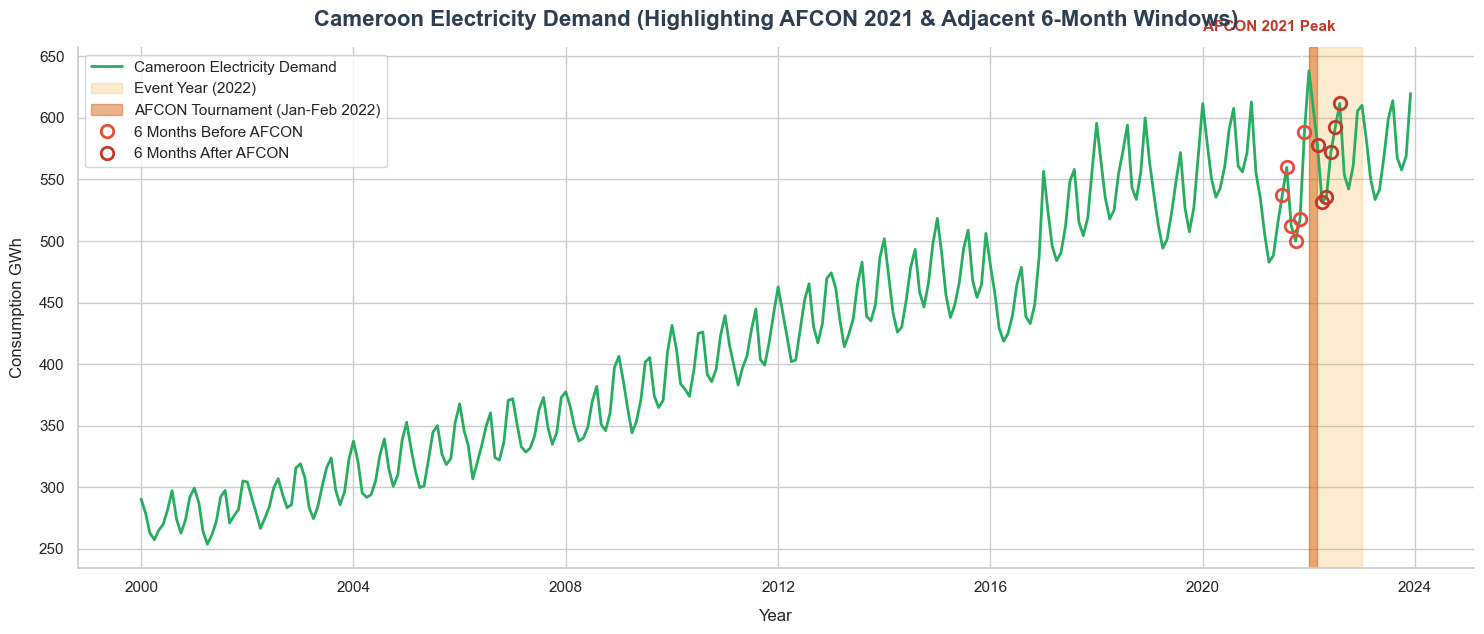

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File path provided
file_path = r"C:\Users\Hp\OneDrive\Desktop\Data\Data Time series project\cameroon_monthly_electricity _consumption.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Handle the datetime index dynamically
if 'Year' in df.columns and 'Month' in df.columns:
    df['date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'])
    df = df.set_index('date').sort_index()
elif 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

# Automatically select the first numeric column for the Y-axis if 'Consumption_GWh' isn't explicitly there
val_col = 'Consumption_GWh' if 'Consumption_GWh' in df.columns else df.select_dtypes(include='number').columns[0]

# ─── Plotting ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15, 6.5))

# Plot the main time series
ax.plot(df.index, df[val_col], color="#27ae60", lw=2, label="Cameroon Electricity Demand")

# Highlight the entire AFCON Event Year (2022) with a light shade
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"), 
           color="#f39c12", alpha=0.20, label="Event Year (2022)")

# Highlight the exact tournament months (Jan-Feb 2022) with a darker, distinct color
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-02-28"), 
           color="#d35400", alpha=0.45, label="AFCON Tournament (Jan-Feb 2022)")

# ─── Highlight 6 Months Before & After ────────────────────────────────────
# Define masks for 6 months before (July 2021 to December 2021) and 6 months after (March 2022 to August 2022)
before_mask = (df.index >= "2021-07-01") & (df.index <= "2021-12-01")
after_mask = (df.index >= "2022-03-01") & (df.index <= "2022-08-01")

# Extract the points
before_points = df[before_mask]
after_points = df[after_mask]

# Plot the red circles over the specific points
ax.plot(before_points.index, before_points[val_col], 'o', 
        markerfacecolor='none', markeredgecolor='#e74c3c', markeredgewidth=2, markersize=9, 
        label="6 Months Before AFCON")
ax.plot(after_points.index, after_points[val_col], 'o', 
        markerfacecolor='none', markeredgecolor='#c0392b', markeredgewidth=2, markersize=9, 
        label="6 Months After AFCON")

# Add a specific text annotation pointing to the peak
afcon_peak_date = pd.Timestamp("2022-01-01")
if afcon_peak_date in df.index:
    peak_val = df.loc[afcon_peak_date, val_col]
    ax.annotate("AFCON 2021 Peak", 
                xy=(afcon_peak_date, peak_val),
                xytext=(pd.Timestamp("2020-01-01"), peak_val + (df[val_col].max() * 0.05)),
                arrowprops=dict(facecolor="#c0392b", arrowstyle="->", connectionstyle="arc3,rad=-0.2"),
                fontsize=11, fontweight="bold", color="#c0392b")

# Formatting
ax.set_title("Cameroon Electricity Demand (Highlighting AFCON 2021 & Adjacent 6-Month Windows)", 
             fontsize=16, fontweight="bold", pad=15, color="#2c3e50")
ax.set_ylabel(val_col.replace("_", " "), fontsize=12, labelpad=10)
ax.set_xlabel("Year", fontsize=12, labelpad=10)
ax.legend(frameon=True, facecolor="white", loc="upper left", fontsize=11)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()


In [7]:
import importlib, sarima_residual_extraction as srep
importlib.reload(srep)

# This will take a few minutes as it trains 5 SARIMA models!
df_residuals, sarima_models = srep.run_sarima_residual_pipeline(plot=True)
df_residuals.head()


ModuleNotFoundError: No module named 'sarima_residual_extraction'